# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

# Colab: clone fork (có sẵn submission_2A202602727/) rồi chuyển vào thư mục code/ để các đường dẫn tương đối bên dưới vẫn đúng
if "google.colab" in sys.modules:
    COLAB_REPO = "/content/K4-Track4-Day1-Neuralnetwork"
    if not os.path.isdir(COLAB_REPO):
        subprocess.run(["git", "clone", "https://github.com/nhat-thang/K4-Track4-Day1-Neuralnetwork.git", COLAB_REPO], check=True)
    os.chdir(f"{COLAB_REPO}/submission_2A202602727/code")
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)

# Chọn device: "cuda" nếu có GPU, nếu không thì "mps" (Mac), cuối cùng là "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("PyTorch:", torch.__version__)
print("device :", device)
if device == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))

# Thư mục đầu ra (= submission_2A202602727/figures, results)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

# Kiểm tra đường dẫn trước khi sang Part 0
print("REPO_ROOT:", os.path.abspath(REPO_ROOT))
print("OUT_DIR  :", os.path.abspath(OUT_DIR))
assert os.path.isfile(f"{REPO_ROOT}/scripts/split_data.py"), "REPO_ROOT không trỏ về gốc repo"
assert os.path.isdir(f"{REPO_ROOT}/data"), "không thấy thư mục data/ trong REPO_ROOT"
assert os.path.basename(os.path.abspath(OUT_DIR)) == "submission_2A202602727", "OUT_DIR phải là thư mục nộp"

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.11.0+cu130
device : cuda
GPU    : Tesla T4
REPO_ROOT: /content/K4-Track4-Day1-Neuralnetwork
OUT_DIR  : /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602727


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# ===== Part 0: chia dữ liệu, tách val, chuẩn hoá, đưa lên device =====
subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# Kích thước / kiểu dữ liệu đúng như GUIDE
assert data["X_tr"].shape == (371_847, 54) and data["X_val"].shape == (92_962, 54)
assert data["X_eval"].shape == (116_203, 54)
for k in ("X_tr", "X_val", "X_eval"):
    assert data[k].dtype == torch.float32
for k in ("y_tr", "y_val", "y_eval"):
    assert data[k].dtype == torch.int64 and int(data[k].min()) >= 0 and int(data[k].max()) <= 6

# eval_row_id vẫn khớp thứ tự mẫu eval (so lại với file gốc)
ev = np.load(f"{REPO_ROOT}/data/processed/eval.npz")
assert np.array_equal(data["eval_row_id"], ev["row_id"])
assert np.array_equal(data["y_eval"].cpu().numpy(), ev["y"])
print("eval_row_id:", data["eval_row_id"][:5], "... (len =", len(data["eval_row_id"]), ")")

# Thống kê 10 cột số trên X_tr sau chuẩn hoá ≈ 0 / 1; cột nhị phân giữ nguyên 0/1
num = data["X_tr"][:, :10]
print("mean 10 cột số (X_tr):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (X_tr):", np.round(num.std(0, unbiased=False).cpu().numpy(), 4))
assert torch.allclose(num.mean(0), torch.zeros(10, device=num.device), atol=1e-3)
assert torch.allclose(num.std(0, unbiased=False), torch.ones(10, device=num.device), atol=1e-3)
assert set(torch.unique(data["X_tr"][:, 10:]).tolist()) <= {0.0, 1.0}
# Trên val, mean/std chỉ xấp xỉ 0/1 (không bằng đúng) vì thống kê lấy từ X_tr
print("mean 10 cột số (X_val):", np.round(data["X_val"][:, :10].mean(0).cpu().numpy(), 4))

# Mốc thấp nhất: luôn đoán lớp đa số của train
maj = int(torch.bincount(data["y_tr"], minlength=7).argmax())
maj_acc = (data["y_val"] == maj).float().mean().item()
print(f"Majority baseline (lớp {maj}) — val acc = {maj_acc:.4f}  (GUIDE ≈ 0.4876)")

# Kiểm tra iterate_batches: đủ mẫu, lô cuối nhỏ hơn được giữ lại
from data import iterate_batches
g = torch.Generator(device=data["X_tr"].device).manual_seed(0)
sizes = [len(xb) for xb, _ in iterate_batches(data["X_tr"], data["y_tr"], 512, generator=g)]
print(f"{len(sizes)} lô / epoch, lô cuối = {sizes[-1]} mẫu, tổng = {sum(sizes)}")
assert sum(sizes) == len(data["X_tr"])


tr   : X (371847, 54) torch.float32, y (371847,) torch.int64, device=cuda:0
val  : X (92962, 54) torch.float32, y (92962,) torch.int64, device=cuda:0
eval : X (116203, 54) torch.float32, y (116203,) torch.int64, device=cuda:0
majority baseline (lớp 1) val acc = 0.4876
eval_row_id: [10 11 12 23 34] ... (len = 116203 )
mean 10 cột số (X_tr): [-0. -0. -0.  0. -0. -0. -0. -0. -0.  0.]
std  10 cột số (X_tr): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
mean 10 cột số (X_val): [ 0.0024  0.0021 -0.0024  0.0004 -0.0005  0.0063 -0.0044  0.0022  0.0052
  0.0042]
Majority baseline (lớp 1) — val acc = 0.4876  (GUIDE ≈ 0.4876)
727 lô / epoch, lô cuối = 135 mẫu, tổng = 371847


**Nhận xét Part 0:**
- Kích thước: train 371 847, val 92 962 (20% phân tầng theo nhãn, seed 42), eval 116 203; `X` float32 (N, 54), `y` int64 trong 0..6.
- Chuẩn hoá: mean/std của 10 cột số tính **chỉ trên `X_tr`**, rồi áp dụng cùng mean/std cho train, val, eval; 44 cột nhị phân giữ nguyên. Cột có std = 0 thì chỉ trừ mean (chia cho 1) để tránh chia 0. `apply_standardizer` trả về bản sao, không sửa mảng gốc.
- Vì sao val/eval không tham gia tính mean/std: val và eval đóng vai dữ liệu "chưa thấy". Nếu dùng chúng để tính thống kê, thông tin phân phối của chúng rò rỉ vào bước tiền xử lý (data leakage) → điểm val/eval bị lạc quan và không còn là ước lượng trung thực cho dữ liệu mới. *Áp dụng* phép biến đổi lên val/eval là bắt buộc (model cần đầu vào cùng thang đo); *dùng* chúng để fit phép biến đổi thì không được phép.
- Mốc "luôn đoán lớp đa số" (lớp 1) trên val ≈ 0.4876: mọi model phải vượt xa mức này.
- Lô cuối: giữ lại (không drop_last). Với batch 512, 371 847 = 726·512 + 135 nên mỗi epoch có 727 lô, lô cuối 135 mẫu. Loss CE lấy trung bình trong lô nên lô nhỏ chỉ làm gradient bước đó nhiễu hơn một chút, đổi lại mọi mẫu đều được dùng mỗi epoch.
- `eval_row_id` được giữ nguyên thứ tự mẫu eval (đã đối chiếu với file `eval.npz`) để ghép dự đoán ở Part 4.


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
Số tham số: 47879
  net.0.weight (256, 54)
  net.0.bias   (256,)
  net.2.weight (128, 256)
  net.2.bias   (128,)
  net.4.weight (7, 128)
  net.4.bias   (7,)

input           : (8, 54)
Linear          : (8, 256)
ReLU            : (8, 256)
Linear          : (8, 128)
ReLU            : (8, 128)
Linear          : (8, 7)

Loss bước 0 trên val = 2.3776   (mốc ln 7 = 1.9459, lệch +0.4317)
std của logits bước 0 = 0.647, acc bước 0 = 0.0512

Chuẩn gradient sau một lần backward():
  net.0.weight grad_norm = 0.582299
  net.0.bias   grad_norm = 0.383307
  net.2.weight grad_norm = 2.371695
  net.2.bias   grad_norm = 0.498140
  net.4.weight grad_norm = 2.078331
  net.4.bias   grad_norm = 0.606070

Nhãn của 20 mẫu: [1, 1, 1, 6, 1, 0, 1, 0, 0, 6, 1, 2, 6, 2, 1

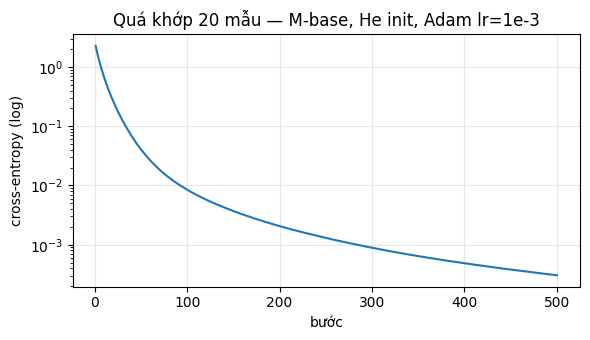

In [3]:
# ===== Part 1: M-base và các phép kiểm tra "sức khoẻ" =====
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- 1. Tạo M-base, kiểm tra số tham số
torch.manual_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
print(model)
print("Số tham số:", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
for name, p in model.named_parameters():
    print(f"  {name:12s} {tuple(p.shape)}")

# --- 2. Một lô ngẫu nhiên (8, 54): in shape sau từng lớp
x = torch.randn(8, 54, device=device)
h = x
print("\ninput           :", tuple(h.shape))
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:16s}:", tuple(h.shape))
logits = model(x)
assert logits.shape == (8, 7) and logits.dtype == torch.float32

# --- 3. Loss bước 0 trên toàn bộ val (eval mode, trước mọi bước cập nhật)
model.eval()
with torch.no_grad():
    val_logits = model(data["X_val"])
    loss0 = F.cross_entropy(val_logits, data["y_val"]).item()
print(f"\nLoss bước 0 trên val = {loss0:.4f}   (mốc ln 7 = {math.log(7):.4f}, lệch {loss0 - math.log(7):+.4f})")
print(f"std của logits bước 0 = {val_logits.std().item():.3f}, acc bước 0 = {(val_logits.argmax(1) == data['y_val']).float().mean().item():.4f}")

# --- 4. Kiểm tra gradient: một lần backward trên một lô train 512 mẫu (model mới, chưa cập nhật)
model.train()
model.zero_grad()
xb, yb = data["X_tr"][:512], data["y_tr"][:512]
F.cross_entropy(model(xb), yb).backward()
print("\nChuẩn gradient sau một lần backward():")
for name, p in model.named_parameters():
    g = None if p.grad is None else p.grad.norm().item()
    print(f"  {name:12s} grad_norm = {g:.6f}" if g is not None else f"  {name:12s} grad = None")
    assert p.grad is not None and g > 0, f"{name} không nhận được gradient"

# --- 5. Quá khớp 20 mẫu: tắt dropout, Adam lr 1e-3, 500 bước, cùng 20 mẫu mỗi bước
torch.manual_seed(42)
overfit_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.randperm(len(data["X_tr"]), device=device)[:20]
x20, y20 = data["X_tr"][idx], data["y_tr"][idx]
print("\nNhãn của 20 mẫu:", y20.tolist())
opt = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)
overfit_losses = []
overfit_model.train()
for step in range(500):
    opt.zero_grad()
    loss = F.cross_entropy(overfit_model(x20), y20)
    loss.backward()
    opt.step()
    overfit_losses.append(loss.item())
    if step in (0, 49, 99, 199, 299, 499):
        print(f"  bước {step + 1:3d}: loss = {loss.item():.6f}")
overfit_model.eval()
with torch.no_grad():
    acc20 = (overfit_model(x20).argmax(1) == y20).float().mean().item()
print(f"Loss cuối = {overfit_losses[-1]:.6f}, accuracy trên 20 mẫu = {acc20:.2%}")
assert overfit_losses[-1] < 0.01 and acc20 == 1.0

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(overfit_losses) + 1), overfit_losses)
ax.set_yscale("log")
ax.set_xlabel("bước"); ax.set_ylabel("cross-entropy (log)")
ax.set_title("Quá khớp 20 mẫu — M-base, He init, Adam lr=1e-3")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figures/part1_overfit20.png", dpi=120)
plt.show()


**Nhận xét Part 1:**
- Kiến trúc: `54 → 256 → 128 → 7`, mọi `Linear` có bias, ReLU sau lớp ẩn, không softmax trong model; số tham số = 47 879, logits shape `(8, 7)`.
- Khởi tạo: `kaiming_normal_(nonlinearity="relu")` (Var = 2/n_in) cho mọi `W`, bias = 0, không phải khởi tạo mặc định của `nn.Linear`.
- Loss bước 0 đo được = **2.3776**, so với ln 7 = 1.9459 (lệch **+0.43**). Nếu mọi logit bằng nhau thì softmax đều 1/7 và CE = ln 7. Ở đây logits có std = **0.647**: chỉ riêng độ phân tán ngẫu nhiên này đã đẩy loss lên khoảng ln 7 + (σ²/2)·(6/7) ≈ 2.13. Phần còn lại (~0.25) nhiều khả năng do một độ lệch chung: 44 cột nhị phân không được trừ mean nên mọi mẫu cùng nghiêng logits về một hướng. Accuracy bước 0 chỉ **0.0512**, thấp hơn cả đoán ngẫu nhiên (≈ 0.14), cho thấy model mới khởi tạo đang đoán lệch có hệ thống về một lớp hiếm. Mức lệch này không phải lỗi: chuẩn hoá đã kiểm tra ở Part 0, gradient chảy tới mọi lớp, và model quá khớp được 20 mẫu. Lệch sẽ lớn hơn nhiều (vài đơn vị) nếu quên chuẩn hoá hoặc lớp cuối khởi tạo quá lớn.
- Quá khớp 20 mẫu: loss giảm từ **2.264** xuống **0.0407** sau 50 bước và **0.000306** sau 500 bước (Adam, lr 1e-3, không dropout), accuracy 100% trên 20 mẫu → model, loss, nhãn và vòng cập nhật (`zero_grad` → `backward` → `step`) phối hợp đúng. Đây chỉ là kiểm tra khả năng khớp, không nói gì về tổng quát hoá.
- Gradient: cả 6 tham số đều có gradient khác `None` và khác 0 sau một lần `backward()` (chuẩn từ 0.38 ở `b1` đến 2.37 ở `W2`) → gradient chảy tới mọi lớp.


## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

lr-0.003   step0=2.2691  best_epoch=20  best_val_loss=0.4195  val_acc=0.8257  val_macro_f1=0.6657  1.3324 s/epoch  diverged=False
lr-0.01    step0=2.2691  best_epoch=20  best_val_loss=0.3106  val_acc=0.8758  val_macro_f1=0.7615  1.3027 s/epoch  diverged=False
lr-0.03    step0=2.2691  best_epoch=18  best_val_loss=0.2672  val_acc=0.8933  val_macro_f1=0.8240  1.3214 s/epoch  diverged=False
lr-0.1     step0=2.2691  best_epoch=18  best_val_loss=0.2332  val_acc=0.9069  val_macro_f1=0.8410  1.3304 s/epoch  diverged=False
lr-0.3     step0=2.2691  best_epoch=20  best_val_loss=0.2221  val_acc=0.9109  val_macro_f1=0.8599  1.3394 s/epoch  diverged=False

lr      best_epoch  best_val_loss  val_acc  val_macro_f1  diverged
0.003           20         0.4195   0.8257        0.6657  False
0.01            20         0.3106   0.8758        0.7615  False
0.03            18         0.2672   0.8933        0.8240  False
0.1             18         0.2332   0.9069        0.8410  False
0.3             20        

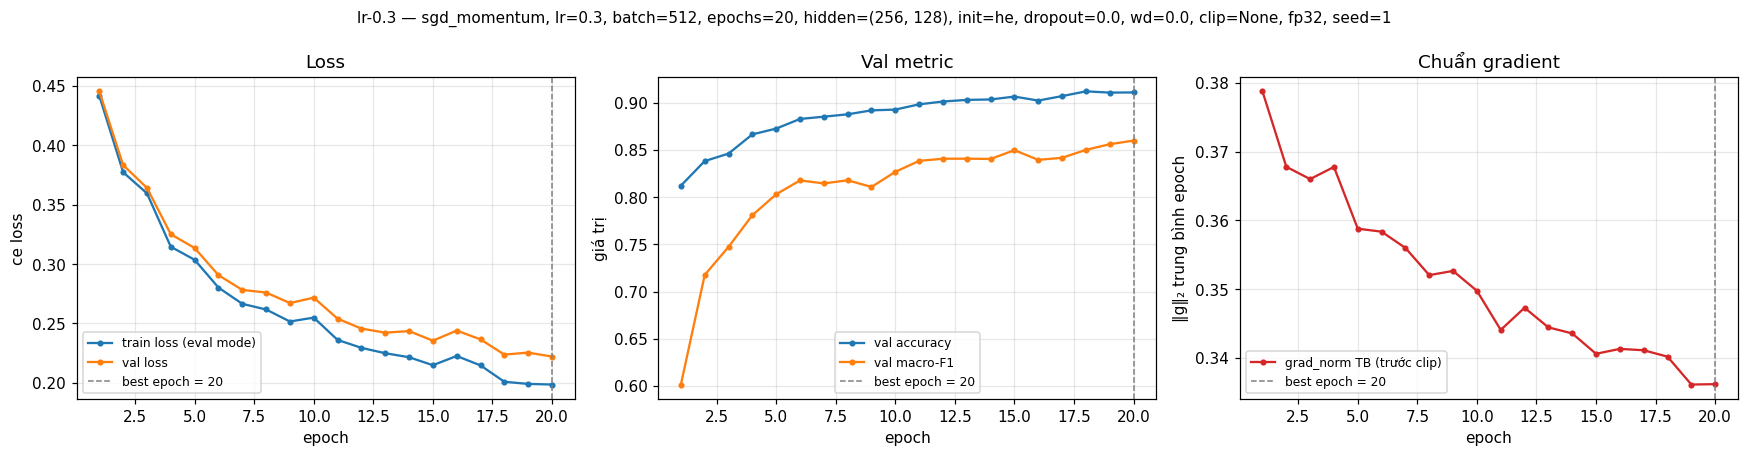

base-s1    step0=2.2691  best_epoch=20  best_val_loss=0.2221  val_acc=0.9109  val_macro_f1=0.8599  1.3443 s/epoch  diverged=False
base-s2    step0=1.9782  best_epoch=19  best_val_loss=0.2215  val_acc=0.9129  val_macro_f1=0.8537  1.3203 s/epoch  diverged=False
base-s3    step0=1.9005  best_epoch=19  best_val_loss=0.2193  val_acc=0.9123  val_macro_f1=0.8603  1.3087 s/epoch  diverged=False


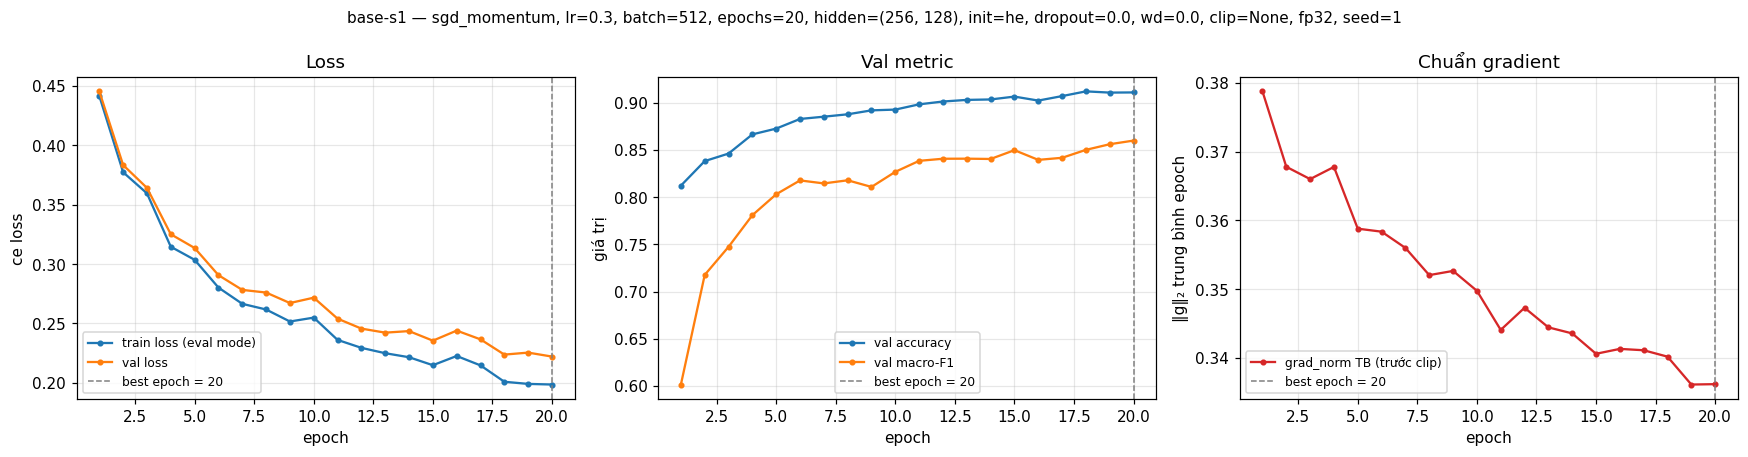

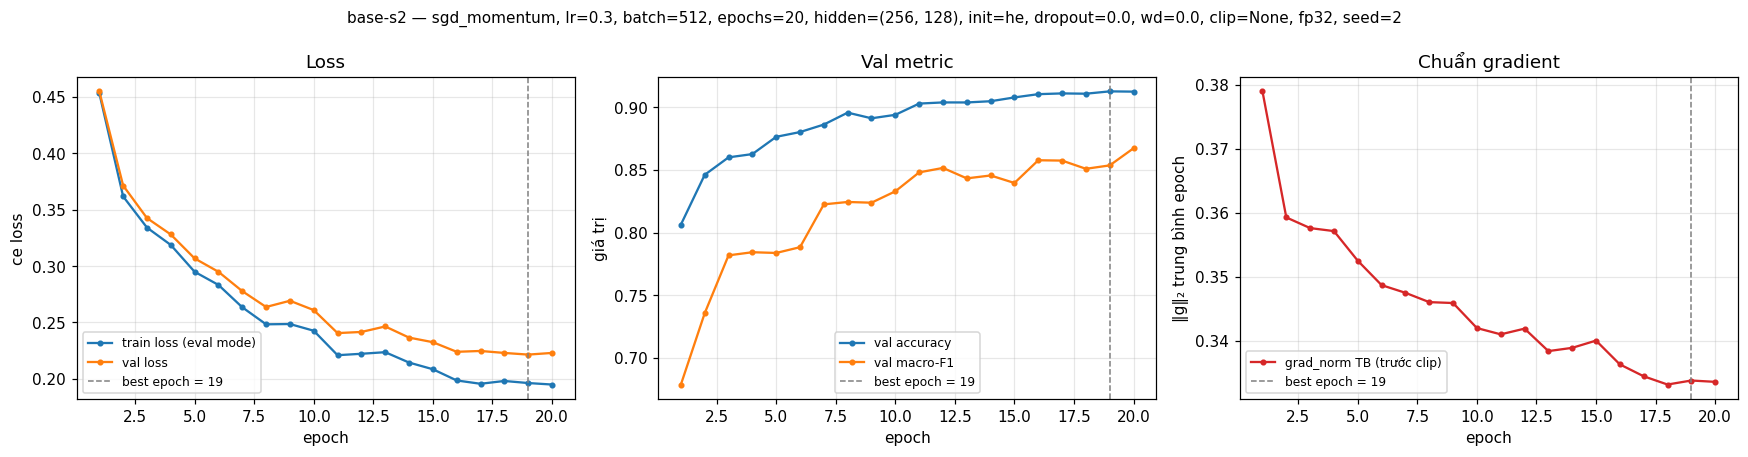

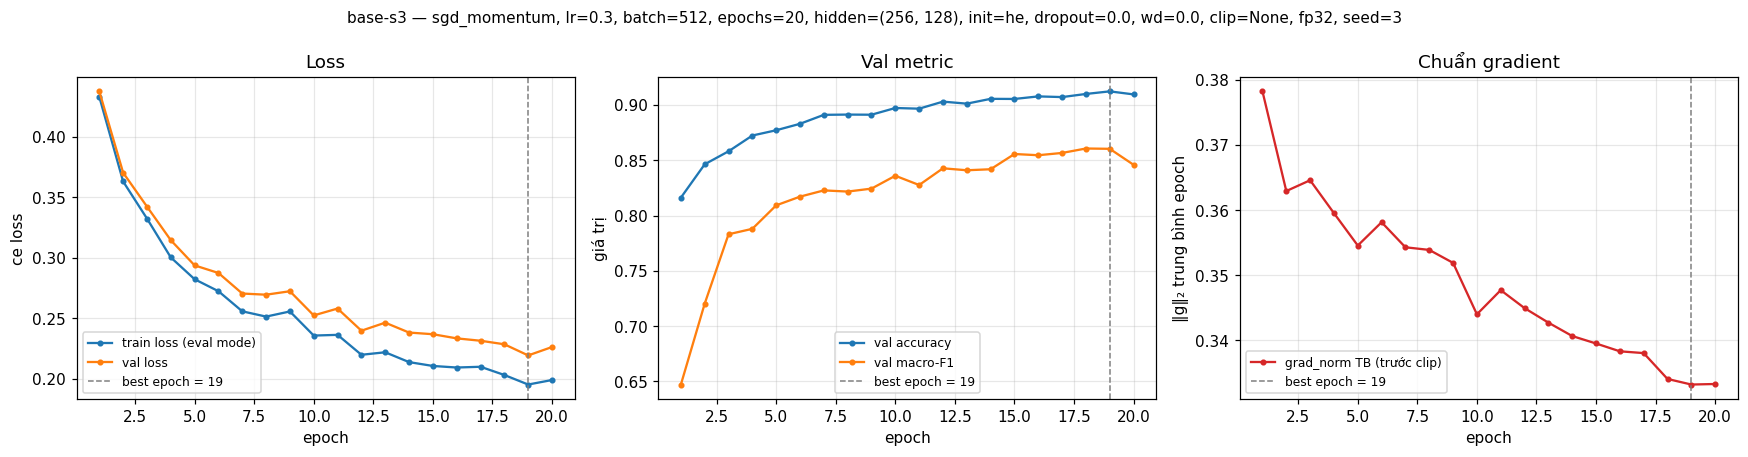


exp_id    best_epoch  best_val_loss  val_acc  val_macro_f1  final_train_loss  final_val_loss
base-s1           20         0.2221   0.9109        0.8599            0.1986          0.2221
base-s2           19         0.2215   0.9129        0.8537            0.1949          0.2229
base-s3           19         0.2193   0.9123        0.8603            0.1990          0.2263
val_acc       : 0.9120 ± 0.0010   (ngưỡng nhiễu 2σ = 0.0020)
val_macro_f1  : 0.8580 ± 0.0037   (ngưỡng nhiễu 2σ = 0.0074)
best_val_loss : 0.2210 ± 0.0015   (ngưỡng nhiễu 2σ = 0.0029)

Mọi seed đều vượt mốc 'đoán lớp đa số' (0.4876).


In [ ]:
# ===== Part 2: chọn lr bằng VAL, rồi chạy baseline nhiều seed =====
from IPython.display import Image, display

def run_and_save(exp_cfg):
    """Chạy một cấu hình, lưu results/<exp_id>.json và figures/<exp_id>.png ngay sau khi chạy."""
    r = run_experiment(exp_cfg, data)
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{exp_cfg['exp_id']}.png")
    s = r["summary"]
    f4 = lambda v: "-" if v is None else f"{v:.4f}"
    print(f"{exp_cfg['exp_id']:10s} step0={f4(s['step0_loss'])}  best_epoch={s['best_epoch']}  "
          f"best_val_loss={f4(s['best_val_loss'])}  val_acc={f4(s['val_acc'])}  "
          f"val_macro_f1={f4(s['val_macro_f1'])}  {f4(s['time_per_epoch_s'])} s/epoch  diverged={s['diverged']}")
    return r

# --- 2a. Tìm lr cho baseline (SGD + momentum 0.9, 20 epoch, seed 1). Chỉ dùng VAL để chọn.
LR_GRID = [0.003, 0.01, 0.03, 0.1, 0.3]
lr_results = {}
for lr in LR_GRID:
    lr_cfg = {**DEFAULT_CFG, "lr": lr, "seed": 1, "exp_id": f"lr-{lr:g}", "group": "lr_search",
              "description": f"Baseline M-base, tìm lr = {lr:g} (seed 1)"}
    lr_results[lr] = run_and_save(lr_cfg)

print("\nlr      best_epoch  best_val_loss  val_acc  val_macro_f1  diverged")
for lr, r in lr_results.items():
    s = r["summary"]
    if s["diverged"] or s["best_epoch"] is None:
        print(f"{lr:<7g} {'-':>10}  {'-':>13}  {'-':>7}  {'-':>12}  {s['diverged']}")
    else:
        print(f"{lr:<7g} {s['best_epoch']:>10d}  {s['best_val_loss']:>13.4f}  {s['val_acc']:>7.4f}  "
              f"{s['val_macro_f1']:>12.4f}  {s['diverged']}")

# Tiêu chí chọn: val macro-F1 tại best epoch cao nhất (chỉ số chính của Lab), bỏ qua lần chạy phân kỳ
ok = {lr: r for lr, r in lr_results.items() if not r["summary"]["diverged"] and r["summary"]["best_epoch"] is not None}
BASE_LR = max(ok, key=lambda lr: ok[lr]["summary"]["val_macro_f1"])
print(f"\n=> lr chọn cho baseline: {BASE_LR:g}")
display(Image(f"{OUT_DIR}/figures/lr-{BASE_LR:g}.png"))

# --- 2b. Baseline với lr đã chọn, 3 seed (đo độ nhiễu). Seed tách val giữ nguyên = 42.
cfg = {**DEFAULT_CFG, "lr": BASE_LR}
SEEDS = [1, 2, 3]
base_results = []
for s in SEEDS:
    base_results.append(run_and_save({**cfg, "seed": s, "exp_id": f"base-s{s}", "group": "baseline",
                                      "description": f"Baseline M-base, lr={BASE_LR:g}, seed {s}"}))
for r in base_results:
    display(Image(f"{OUT_DIR}/figures/{r['cfg']['exp_id']}.png"))

# --- 2c. Độ nhiễu giữa các seed: trung bình ± độ lệch chuẩn (ddof=1) và ngưỡng 2σ
print("\nexp_id    best_epoch  best_val_loss  val_acc  val_macro_f1  final_train_loss  final_val_loss")
for r in base_results:
    s = r["summary"]
    print(f"{r['cfg']['exp_id']:9s} {s['best_epoch']:>10d}  {s['best_val_loss']:>13.4f}  {s['val_acc']:>7.4f}  "
          f"{s['val_macro_f1']:>12.4f}  {s['final_train_loss']:>16.4f}  {s['final_val_loss']:>14.4f}")
noise = {}
for key in ("val_acc", "val_macro_f1", "best_val_loss"):
    vals = np.array([r["summary"][key] for r in base_results])
    noise[key] = (vals.mean(), vals.std(ddof=1))
    print(f"{key:14s}: {vals.mean():.4f} ± {vals.std(ddof=1):.4f}   (ngưỡng nhiễu 2σ = {2 * vals.std(ddof=1):.4f})")

maj_acc = 0.4876
assert all(r["summary"]["val_acc"] > maj_acc for r in base_results), "val_acc phải vượt mốc đoán đa số"
print(f"\nMọi seed đều vượt mốc 'đoán lớp đa số' ({maj_acc}).")


**Nhận xét baseline:**
- **Chọn lr bằng val** (SGD + momentum 0.9, 20 epoch, seed 1; tiêu chí: val macro-F1 tại best epoch):

  | lr | best epoch | best val loss | val acc | val macro-F1 |
  |---|---|---|---|---|
  | 0.003 | 20 | 0.4195 | 0.8257 | 0.6657 |
  | 0.01 | 20 | 0.3106 | 0.8758 | 0.7615 |
  | 0.03 | 18 | 0.2672 | 0.8933 | 0.8240 |
  | 0.1 | 18 | 0.2332 | 0.9069 | 0.8410 |
  | **0.3** | 20 | **0.2221** | **0.9109** | **0.8599** |

  lr được chọn = **0.3**. Mọi chỉ số tăng đều theo lr và không lần nào phân kỳ: lr nhỏ (0.003, 0.01) học quá chậm, sau 20 epoch val loss vẫn còn cao và còn giảm. **Hạn chế:** 0.3 là giá trị lớn nhất trong lưới, nên chưa biết lr tốt nhất có nằm trên 0.3 hay không; muốn chắc cần thử thêm 0.5 và 1.0.
- **Hình dạng đường cong (base-s1..s3):** train loss và val loss cùng giảm và gần như song song; best epoch = 19–20, val loss cuối (0.222–0.226) gần bằng best (0.219–0.222) → model **vẫn đang học, chưa quá khớp** sau 20 epoch. Khoảng cách val − train tăng dần từ ≈ 0 ở epoch 1 lên ≈ 0.024–0.028 ở epoch 20, vẫn nhỏ → chưa quá khớp, dù đã bắt đầu tách nhẹ. Đường loss có vài gợn nhỏ (ví dụ epoch 10, 16 ở base-s1) do lr 0.3 khá lớn, nhưng xu hướng vẫn giảm; grad_norm trung bình giảm đều từ ≈ 0.38 xuống ≈ 0.34. Nhiều khả năng còn cải thiện được nếu chạy thêm epoch.
- **So với mốc:** val acc ≈ **0.912** ≫ 0.4876 (luôn đoán lớp 1); val macro-F1 ≈ **0.858** so với ≈ 0.094 của chiến lược đoán đa số. macro-F1 thấp hơn accuracy khá nhiều, nhiều khả năng vì các lớp hiếm (lớp 3 chỉ ~0.5%) được dự đoán kém hơn lớp lớn (sẽ kiểm tra bằng F1 theo lớp ở Part 4).
- **Loss bước 0:** 2.2691 / 1.9782 / 1.9005 với seed 1 / 2 / 3 (Part 1, seed 42: 2.3776), so với ln 7 = 1.946. Độ lệch thay đổi mạnh theo seed khởi tạo: có seed gần như đúng ln 7, có seed cao hơn ~0.3–0.4. Như vậy lệch ở Part 1 chủ yếu do lần khởi tạo cụ thể (logits ban đầu nghiêng về một lớp), không phải lỗi pipeline.
- **Độ nhiễu giữa 3 seed** (seed tách val giữ 42, chỉ đổi seed khởi tạo + thứ tự lô):
  - val acc = 0.9120 ± 0.0010 → ngưỡng 2σ = 0.0020
  - val macro-F1 = 0.8580 ± 0.0037 → ngưỡng 2σ = **0.0074**
  - best val loss = 0.2210 ± 0.0015 → ngưỡng 2σ = 0.0029

  Ở Part 3, một thay đổi chỉ được coi là tốt hơn/tệ hơn baseline khi chênh lệch val macro-F1 vượt ≈ 0.0074 (với 3 seed, ước lượng σ này cũng còn khá thô).
- **Cách đo:** train loss đo ở chế độ `eval()` trên 50 000 mẫu cố định của train; grad_norm là chuẩn L2 toàn cục trước khi clip, lấy trung bình trong epoch; thời gian epoch (~1.3 s trên T4) chỉ tính phần huấn luyện, có `torch.cuda.synchronize()`.


## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Quy ước chung cho Part 3
- **Tham chiếu:** `base-s1` (SGD + momentum 0.9, lr 0.3, batch 512, 20 epoch, He, CE, FP32, **seed 1**). Mọi thí nghiệm dưới đây cũng dùng seed 1, cùng phép tách val (seed 42), cùng 20 epoch; chỉ đổi yếu tố đang khảo sát. Khi buộc phải đổi hai yếu tố, lý do được ghi trong `notes`.
- **Ngưỡng nhiễu:** từ 3 seed baseline (Part 2), σ(val macro-F1) ≈ 0.0037 → chỉ coi là khác baseline khi |Δ macro-F1| > 2σ ≈ 0.0074. σ ước lượng từ 3 seed còn thô, và các thí nghiệm chỉ chạy 1 seed, nên chênh lệch gần ngưỡng vẫn là "chưa kết luận được".
- **Chọn bằng val:** mọi so sánh dùng val loss / val acc / val macro-F1 tại best epoch (epoch có val loss thấp nhất). Tập eval không được dùng ở Part 3.
- Mỗi lần chạy lưu `results/<exp_id>.json` và `figures/<exp_id>.png`; mỗi nhóm có ảnh chồng `figures/compare_<nhóm>.png`.
- Nếu Colab ngắt kết nối giữa chừng: chạy lại các ô; lần chạy nào đã có JSON sẽ được nạp lại thay vì chạy lại (`RERUN = False`).

In [4]:
# ===== Part 3: khung chung cho mọi thí nghiệm =====
import math
import torch.nn.functional as F
from IPython.display import Image, display
from model import activation_stats

RESULTS_DIR, FIG_DIR = f"{OUT_DIR}/results", f"{OUT_DIR}/figures"
RERUN = False   # False: nếu results/<exp_id>.json đã có thì nạp lại thay vì chạy lại


def load_json(exp_id):
    with open(f"{RESULTS_DIR}/{exp_id}.json", encoding="utf-8") as f:
        return json.load(f)


# Baseline (đã chạy ở Part 2): base-s1 là tham chiếu, base-s1..s3 cho độ nhiễu seed
cfg = {**DEFAULT_CFG}
assert cfg["lr"] == 0.3, "DEFAULT_CFG phải mang lr đã chọn ở Part 2"
base_runs = [load_json(f"base-s{s}") for s in (1, 2, 3)]
BASE = base_runs[0]
F1_SIGMA = float(np.std([r["summary"]["val_macro_f1"] for r in base_runs], ddof=1))
NOISE = 2 * F1_SIGMA
print(f"base-s1: val_macro_f1 = {BASE['summary']['val_macro_f1']:.4f}, val_acc = {BASE['summary']['val_acc']:.4f}")
print(f"σ(val macro-F1) qua 3 seed = {F1_SIGMA:.4f}  ->  ngưỡng nhiễu 2σ = {NOISE:.4f}")

ALL_RUNS = {"base-s1": BASE}
FAILED = {}   # exp_id -> lý do (ghi vào notes của bảng ở Part 4)


def run_exp(exp_id, group, description, notes="", **changes):
    """Tạo cfg từ baseline + các thay đổi, chạy (hoặc nạp lại JSON), lưu kết quả và ảnh riêng."""
    unknown = set(changes) - set(DEFAULT_CFG)
    assert not unknown, f"khoá cfg không tồn tại: {unknown}"
    exp_cfg = {**cfg, **changes, "seed": 1, "exp_id": exp_id, "group": group,
               "description": description, "notes": notes}
    if not RERUN and os.path.exists(f"{RESULTS_DIR}/{exp_id}.json"):
        r = load_json(exp_id)
        print(f"(nạp lại {exp_id} từ JSON)")
    else:
        try:
            r = run_experiment(exp_cfg, data)
        except Exception as e:   # ví dụ BF16 không được hỗ trợ: ghi lại lý do, không làm hỏng cả ô
            FAILED[exp_id] = f"{type(e).__name__}: {e}"
            print(f"[{exp_id}] KHÔNG CHẠY ĐƯỢC -> {FAILED[exp_id]}")
            return None
        save_result(r, RESULTS_DIR)
    plot_run(r, f"{FIG_DIR}/{exp_id}.png")
    ALL_RUNS[exp_id] = r
    return r


def epochs_to(r, key="val_acc", target=0.88):
    """Epoch đầu tiên đạt ngưỡng (đo tốc độ hội tụ); None nếu không đạt."""
    for e, v in zip(r["history"]["epoch"], r["history"][key]):
        if v >= target:
            return e
    return None


def show_table(exp_ids, title=""):
    """In bảng so sánh với base-s1: Δ macro-F1 và có vượt ngưỡng nhiễu 2σ hay không."""
    b = BASE["summary"]["val_macro_f1"]
    if title:
        print(f"\n=== {title} ===")
    print(f"{'exp_id':24s} {'best_ep':>7s} {'best_vl':>8s} {'val_acc':>8s} {'val_F1':>7s} {'ΔF1':>8s} {'vượt 2σ?':>9s} "
          f"{'gap_cuối':>8s} {'ep→acc.88':>9s} {'s/epoch':>7s} {'MB':>6s}  diverged")
    for e in ["base-s1"] + [x for x in exp_ids if x != "base-s1"]:
        r = ALL_RUNS.get(e)
        if r is None:
            print(f"{e:24s} không chạy được: {FAILED.get(e, '?')}")
            continue
        s, h = r["summary"], r["history"]
        if s["best_epoch"] is None:
            print(f"{e:24s} {'-':>7s} ... phân kỳ ngay từ đầu, diverged={s['diverged']}")
            continue
        d = s["val_macro_f1"] - b
        verdict = "-" if e == "base-s1" else ("CÓ" if abs(d) > NOISE else "không")
        gap = s["final_val_loss"] - s["final_train_loss"]
        mem = s["peak_mem_MB"] if s["peak_mem_MB"] is not None else float("nan")
        print(f"{e:24s} {s['best_epoch']:>7d} {s['best_val_loss']:>8.4f} {s['val_acc']:>8.4f} {s['val_macro_f1']:>7.4f} "
              f"{d:>+8.4f} {verdict:>9s} {gap:>8.4f} {str(epochs_to(r)):>9s} {s['time_per_epoch_s']:>7.2f} "
              f"{mem:>6.0f}  {s['diverged']}")


def compare(exp_ids, metric, name, title):
    rs = [ALL_RUNS[e] for e in (["base-s1"] + [x for x in exp_ids if x != "base-s1"]) if e in ALL_RUNS]
    path = f"{FIG_DIR}/compare_{name}.png"
    plot_compare(rs, metric, path, title)
    display(Image(path))

base-s1: val_macro_f1 = 0.8599, val_acc = 0.9109
σ(val macro-F1) qua 3 seed = 0.0037  ->  ngưỡng nhiễu 2σ = 0.0074


### Thí nghiệm `loss-mse-lr0.3`, `loss-mse-lr1` — chủ đề `loss`
**Câu hỏi:** thay cross-entropy bằng MSE giữa logit và one-hot thì học nhanh/chậm thế nào, và đạt metric ra sao?

**Cách tính MSE:** như `nn.MSELoss` — không có hệ số 1/2, trung bình trên **mọi phần tử** (B × 7). Hai loss khác thang đo nên **chỉ so val acc, val macro-F1 và tốc độ hội tụ** (epoch đầu đạt val acc 0.88), không so giá trị loss.

**Dự đoán trước:** với CE, ∂L/∂z = (softmax(z) − y)/B: không bão hoà, sai càng nặng gradient càng lớn. Với MSE, ∂L/∂z = 2(z − y)/(7B): nhỏ hơn khoảng 3.5 lần ở cùng độ lệch, và còn kéo logit các lớp sai về đúng 0 thay vì chỉ cần nhỏ hơn lớp đúng. Vì vậy ở cùng lr 0.3, MSE sẽ hội tụ chậm hơn và macro-F1 thấp hơn baseline (vượt nhiễu), lớp hiếm bị ảnh hưởng nhiều nhất. `loss-mse-lr1` (đổi thêm lr để bù gradient nhỏ hơn, ghi trong `notes`) sẽ thu hẹp khoảng cách nhưng vẫn không bằng CE.


=== loss: CE vs MSE (không so giá trị loss, chỉ so metric) ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
loss-mse-lr0.3                20   0.0275   0.8801  0.7649  -0.0949        CÓ   0.0008        20    1.36    167  False
loss-mse-lr1                  20   0.0469   0.7841  0.5837  -0.2762        CÓ   0.0002      None    1.32    167  False


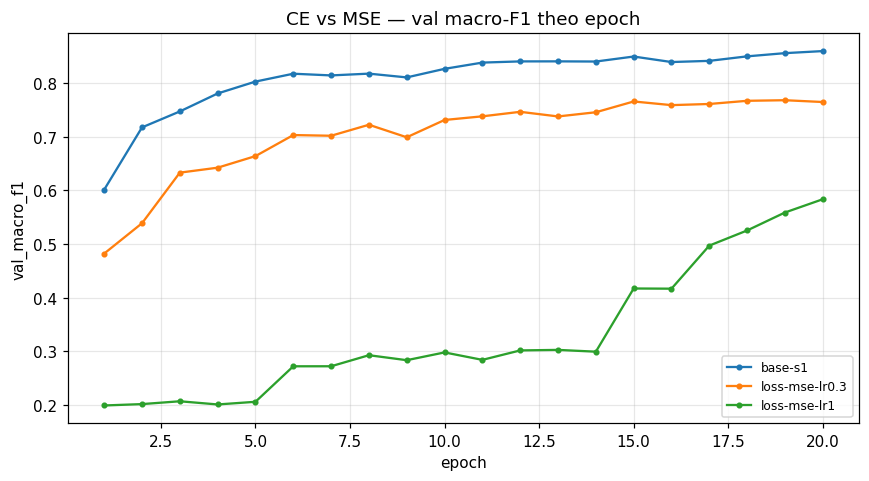

In [5]:
# ===== Chủ đề 1 — loss: CE (baseline) vs MSE trên one-hot =====
LOSS_IDS = []
r = run_exp("loss-mse-lr0.3", "loss", "MSE (logit vs one-hot) thay CE, lr 0.3", loss="mse")
LOSS_IDS.append("loss-mse-lr0.3")
r = run_exp("loss-mse-lr1", "loss", "MSE thay CE, lr 1.0",
            notes="đổi 2 yếu tố (loss + lr): gradient MSE nhỏ hơn ~3.5 lần nên thử lr lớn hơn", loss="mse", lr=1.0)
LOSS_IDS.append("loss-mse-lr1")
show_table(LOSS_IDS, "loss: CE vs MSE (không so giá trị loss, chỉ so metric)")
compare(LOSS_IDS, "val_macro_f1", "loss", "CE vs MSE — val macro-F1 theo epoch")

**Đối chiếu (loss):** Đúng một nửa. MSE kém CE rõ rệt như dự đoán: `loss-mse-lr0.3` macro-F1 = 0.7649 (ΔF1 = −0.0949, vượt 2σ), và chỉ chạm val acc 0.88 ở đúng epoch 20 (baseline chạm ở epoch 6) → hội tụ chậm hơn nhiều. **Khác dự đoán:** tăng lr lên 1.0 không thu hẹp khoảng cách mà làm tệ hơn hẳn: `loss-mse-lr1` = 0.5837 (ΔF1 = −0.2762), không bao giờ đạt val acc 0.88. Ý "lr lớn bù cho gradient MSE nhỏ" chỉ đúng khi gradient nhỏ đều. Thực tế gradient MSE tỉ lệ với (z − y) trên **cả 7 logit**, nên lr lớn khuếch đại luôn lực kéo các logit lớp sai về đúng 0. Các logit dao động quanh mục tiêu thay vì tách lớp đúng ra khỏi lớp sai như CE (CE chỉ cần lớp đúng lớn hơn các lớp khác). Đây là giải thích hợp lý, chưa được đo trực tiếp. Giá trị loss MSE (0.0275, 0.0469) không so được với CE (0.2221) vì khác thang đo, nên ở đây chỉ so metric.

### Thí nghiệm `opt-*` — chủ đề `optimizer`
**Câu hỏi:** ở lr tốt nhất của mỗi bộ, SGD, SGD+momentum, Adam và AdamW khác nhau thế nào?

**Thiết kế:** mỗi bộ ≥ 2 lr, cách nhau khoảng 3 lần; so ở lr tốt nhất (theo val macro-F1) của từng bộ.
- SGD + momentum 0.9: dùng lưới lr của Part 2 (`lr-0.003` … `lr-0.3`) cộng `hp-lr0.6`, `hp-lr1` ở chủ đề hyper-parameter.
- SGD (không momentum): lr {0.3, 1, 3}.
- Adam (β = (0.9, 0.999), ε = 1e-8, wd = 0): lr {3e-4, 1e-3, 3e-3}.
- AdamW (cùng β, ε; wd = 0.01): lr {1e-3, 3e-3}. Đổi cả optimizer lẫn wd, có ghi trong `notes`.

**Dự đoán trước:** momentum tích luỹ gradient nên bước hiệu dụng ≈ lr/(1 − μ) = 10·lr. Vì vậy SGD không momentum ở lr 0.3 sẽ chậm hơn rõ, còn ở lr 3 sẽ xấp xỉ baseline. Adam chia gradient cho √v̂ nên ít nhạy với lr hơn và hội tụ nhanh ở vài epoch đầu (đạt val acc 0.88 sớm hơn). Sau 20 epoch, Adam ở lr tốt nhất sẽ ngang hoặc nhỉnh hơn baseline, nhưng chênh lệch có thể nằm trong nhiễu. AdamW với wd = 0.01 sẽ gần như Adam vì baseline chưa quá khớp.


=== optimizer = sgd ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
opt-sgd-lr0.3                 18   0.2850   0.8838  0.8090  -0.0509        CÓ   0.0115        18    1.22    167  False
opt-sgd-lr1                   18   0.2604   0.8942  0.8359  -0.0240        CÓ   0.0240        13    1.25    167  False
opt-sgd-lr3                   18   0.3296   0.8731  0.6725  -0.1873        CÓ   0.0148      None    1.22    167  False

=== optimizer = adam ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
opt-adam-lr0.0003             20   0.3139   0.8728  0.7874  -0.0724        CÓ   0.0098      None    1.39    16

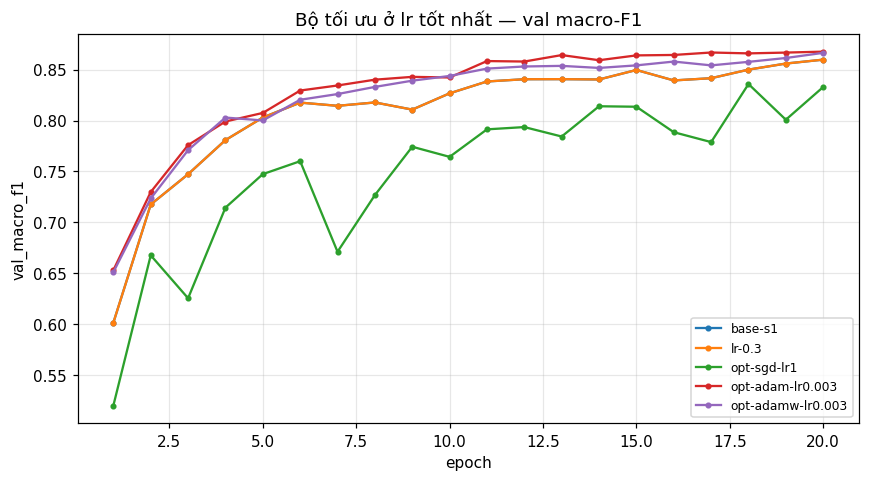

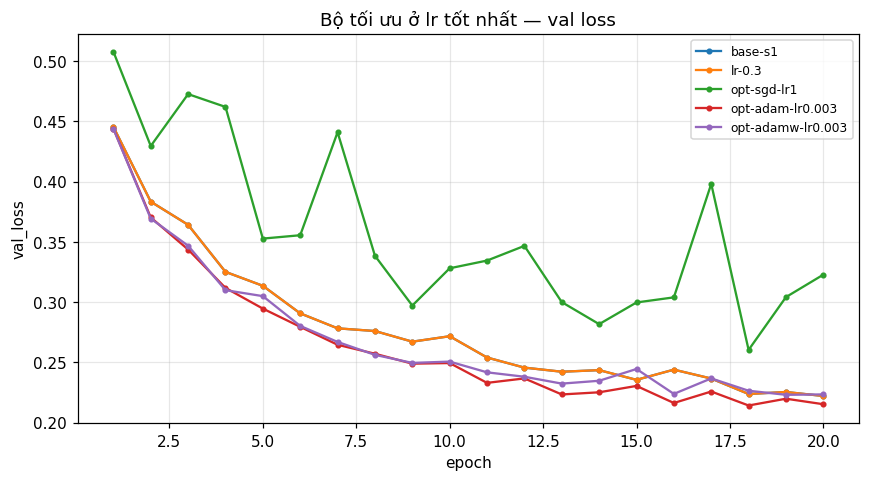

In [6]:
# ===== Chủ đề 2 — optimizer: mỗi bộ >= 2 lr, so ở lr tốt nhất của từng bộ =====
OPT_GRID = {
    "sgd":   [0.3, 1.0, 3.0],
    "adam":  [3e-4, 1e-3, 3e-3],
    "adamw": [1e-3, 3e-3],
}
OPT_IDS = {"sgd_momentum": []}
for e in ("lr-0.003", "lr-0.01", "lr-0.03", "lr-0.1", "lr-0.3"):   # lưới SGD+momentum từ Part 2
    ALL_RUNS[e] = load_json(e)
    OPT_IDS["sgd_momentum"].append(e)
for opt_name, lrs in OPT_GRID.items():
    OPT_IDS[opt_name] = []
    for lr in lrs:
        eid = f"opt-{opt_name}-lr{lr:g}"
        extra = {"weight_decay": 0.01} if opt_name == "adamw" else {}
        notes = "betas=(0.9,0.999), eps=1e-8" if opt_name in ("adam", "adamw") else "momentum=0"
        if opt_name == "adamw":
            notes += "; đổi 2 yếu tố (optimizer + weight_decay=0.01, wd tách riêng kiểu AdamW)"
        run_exp(eid, "optimizer", f"{opt_name}, lr={lr:g}", notes=notes, optimizer=opt_name, lr=lr, **extra)
        OPT_IDS[opt_name].append(eid)
    show_table(OPT_IDS[opt_name], f"optimizer = {opt_name}")
show_table(OPT_IDS["sgd_momentum"], "optimizer = sgd_momentum (lưới Part 2, seed 1)")


def best_of(ids):
    ok = [e for e in ids if e in ALL_RUNS and ALL_RUNS[e]["summary"]["best_epoch"] is not None
          and not ALL_RUNS[e]["summary"]["diverged"]]
    return max(ok, key=lambda e: ALL_RUNS[e]["summary"]["val_macro_f1"]) if ok else None


BEST_OPT = {k: best_of(v) for k, v in OPT_IDS.items()}
print("\nlr tốt nhất của từng bộ (theo val macro-F1):", BEST_OPT)
best_ids = [e for e in BEST_OPT.values() if e]
show_table(best_ids, "so sánh ở lr tốt nhất của mỗi bộ")
compare(best_ids, "val_macro_f1", "optimizer", "Bộ tối ưu ở lr tốt nhất — val macro-F1")
compare(best_ids, "val_loss", "optimizer_val_loss", "Bộ tối ưu ở lr tốt nhất — val loss")

**Đối chiếu (optimizer):** lr tốt nhất của từng bộ (theo val macro-F1): SGD+momentum → 0.3 (`base-s1`), SGD → 1.0, Adam → 0.003, AdamW → 0.003.
- **SGD không momentum** ở lr tốt nhất (`opt-sgd-lr1`: 0.8359, ΔF1 = −0.0240, vượt 2σ) vẫn kém baseline. Dự đoán "SGD lr 3 ≈ baseline vì bước hiệu dụng ≈ lr/(1 − μ)" **sai**: `opt-sgd-lr3` = 0.6725, tệ hơn hẳn lr 1. Quy tắc 1/(1 − μ) chỉ đúng khi gradient giữ nguyên hướng qua nhiều bước. Momentum còn **trung bình hoá** nhiễu giữa các lô, còn SGD lr 3 nhận nguyên nhiễu của từng lô với bước rất lớn.
- **Adam** (`opt-adam-lr0.003`: 0.8660, ΔF1 = +0.0061) và **AdamW** (`opt-adamw-lr0.003`: 0.8615, +0.0016) ngang baseline, **không vượt ngưỡng nhiễu** 0.0074. Đúng dự đoán "ngang hoặc nhỉnh hơn, có thể trong nhiễu". Adam đạt val acc 0.88 ở epoch 6, bằng baseline, không nhanh hơn như dự đoán. Có thể vì baseline lr 0.3 cũng đã hội tụ nhanh. Ở lr nhỏ, Adam tụt rõ (lr 3e-4: 0.7874), nên với 20 epoch Adam vẫn nhạy với lr.
- AdamW (wd 0.01) không khác Adam ngoài nhiễu, khớp dự đoán vì baseline chưa quá khớp.
- **Kết luận:** sau khi so ở lr tốt nhất của mỗi bộ, chưa có bằng chứng bộ tối ưu nào tốt hơn SGD+momentum lr 0.3. Chỉ có 1 seed cho mỗi lần chạy.

### Thí nghiệm `hp-*` — chủ đề `hparam`
**Câu hỏi và dự đoán trước:**
- **lr 0.6, 1.0** (`hp-lr0.6`, `hp-lr1`): mở rộng lưới vì ở Part 2, 0.3 nằm ở biên lưới. Dự đoán: 0.6 có thể nhỉnh hơn 0.3 (vẫn trong nhiễu). Với lr 1.0 cộng momentum 0.9, bước hiệu dụng ≈ 10 nên đường loss sẽ dao động rõ hoặc tệ hơn.
- **batch 128 / 2048** (`hp-batch128`, `hp-batch2048`): cùng 20 epoch nhưng số bước cập nhật khác nhau (2 906 / 727 / 182 bước mỗi epoch). Dự đoán: batch 128 có gấp 4 lần số bước nên val tốt hơn sau 20 epoch, nhưng mỗi epoch chậm hơn khoảng 3–4 lần. Batch 2048 chỉ có ¼ số bước nên kém hơn rõ, nhưng mỗi epoch nhanh hơn.
- **batch 2048 + lr × 4 = 1.2** (`hp-batch2048-lr1.2`, quy tắc tăng lr theo lô, không khởi động; đổi 2 yếu tố, ghi trong `notes`): bù lại phần lớn số bước bị mất. Tuy nhiên lr 1.2 cộng momentum có thể dao động vì không có warm-up.
- **M-wide** `54 → 512 → 256 → 7` (`hp-wide`, 161 287 tham số): baseline chưa quá khớp nên thêm năng lực có thể cải thiện nhẹ val. Dự đoán chênh lệch nhỏ, có thể trong nhiễu; thời gian mỗi epoch tăng ít vì GPU chưa bão hoà.

hp-lr0.6               batch=  512  bước/epoch =   727  tổng bước 20 epoch = 14540
hp-lr1                 batch=  512  bước/epoch =   727  tổng bước 20 epoch = 14540
hp-batch128            batch=  128  bước/epoch =  2906  tổng bước 20 epoch = 58120
hp-batch2048           batch= 2048  bước/epoch =   182  tổng bước 20 epoch = 3640
hp-batch2048-lr1.2     batch= 2048  bước/epoch =   182  tổng bước 20 epoch = 3640
hp-wide                batch=  512  bước/epoch =   727  tổng bước 20 epoch = 14540

=== hyper-parameter ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
hp-lr0.6                      18   0.2700   0.8895  0.8205  -0.0393        CÓ   0.0188        15    1.25    167  False
hp-lr1                        19   0.3308   0.8695  0.7804  -0.0795        CÓ   0.0161      None    1.26    167  False


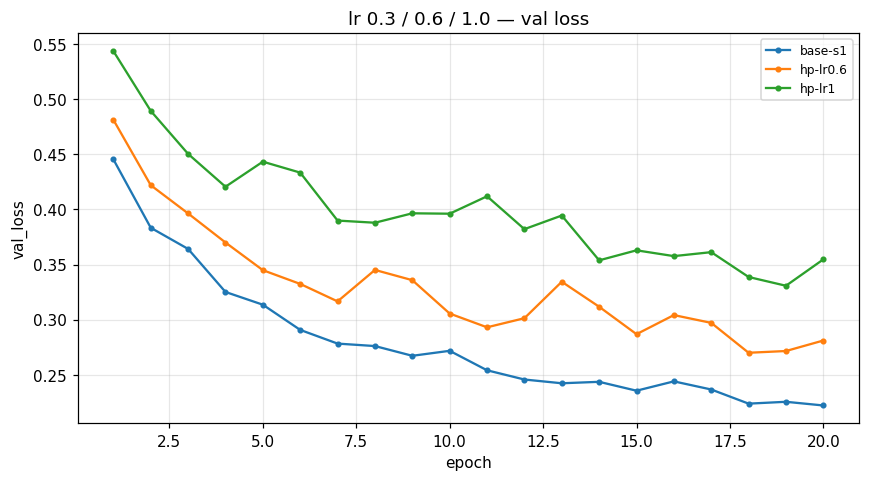

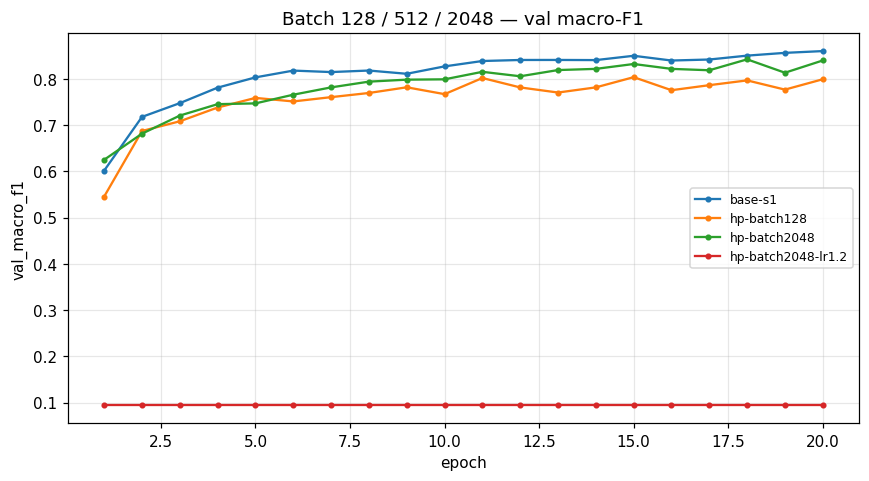

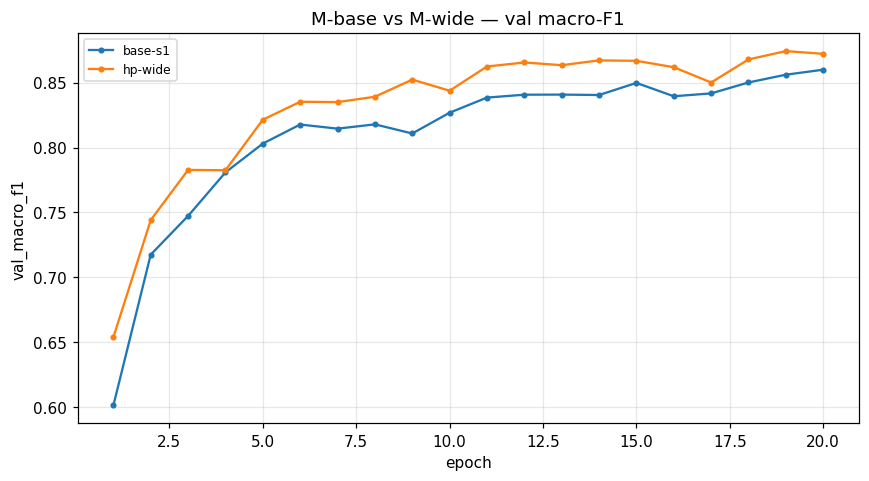

In [7]:
# ===== Chủ đề 3 — hyper-parameter =====
HP_IDS = []
for lr in (0.6, 1.0):
    run_exp(f"hp-lr{lr:g}", "hparam", f"SGD+momentum, lr={lr:g} (mở rộng lưới Part 2)", lr=lr)
    HP_IDS.append(f"hp-lr{lr:g}")
OPT_IDS["sgd_momentum"] += [e for e in ("hp-lr0.6", "hp-lr1") if e in ALL_RUNS]
for b in (128, 2048):
    run_exp(f"hp-batch{b}", "hparam", f"batch {b} (lr giữ 0.3)", batch=b)
    HP_IDS.append(f"hp-batch{b}")
run_exp("hp-batch2048-lr1.2", "hparam", "batch 2048, lr 1.2 (quy tắc lr x4 theo lô)",
        notes="đổi 2 yếu tố (batch + lr), quy tắc tăng lr tuyến tính theo lô, không warm-up", batch=2048, lr=1.2)
HP_IDS.append("hp-batch2048-lr1.2")
assert count_params(MLP(hidden=(512, 256))) == EXPECTED_PARAMS[(512, 256)] == 161_287
run_exp("hp-wide", "hparam", "M-wide 54-512-256-7 (161 287 tham số)", hidden=(512, 256))
HP_IDS.append("hp-wide")

for e in HP_IDS:
    if e in ALL_RUNS:
        b = ALL_RUNS[e]["cfg"]["batch"]
        print(f"{e:22s} batch={b:5d}  bước/epoch = {math.ceil(len(data['X_tr']) / b):5d}  "
              f"tổng bước 20 epoch = {20 * math.ceil(len(data['X_tr']) / b)}")
show_table(HP_IDS, "hyper-parameter")
compare([e for e in HP_IDS if e.startswith("hp-lr")], "val_loss", "hparam_lr", "lr 0.3 / 0.6 / 1.0 — val loss")
compare([e for e in HP_IDS if "batch" in e], "val_macro_f1", "hparam_batch", "Batch 128 / 512 / 2048 — val macro-F1")
compare(["hp-wide"], "val_macro_f1", "hparam_width", "M-base vs M-wide — val macro-F1")

**Đối chiếu (hparam):**
- **`hp-wide` là kết quả tốt nhất của Part 3:** macro-F1 = 0.8721 (ΔF1 = +0.0122, **vượt 2σ**), best val loss = 0.1993 (thấp nhất), đạt val acc 0.88 ở epoch 5 so với epoch 6 của baseline. Tốt hơn dự đoán ("có thể trong nhiễu"). Baseline chưa quá khớp, nên thêm năng lực (3.4 lần tham số) giúp thật. Gap val − train tăng nhẹ (0.0235 → 0.0317), dấu hiệu bắt đầu khớp sát dữ liệu hơn. Thời gian mỗi epoch không đổi (1.28 s so với 1.34 s) vì GPU chưa bão hoà, đúng dự đoán.
- **lr 0.6 / 1.0** đều kém lr 0.3 (−0.0393 / −0.0795, vượt 2σ) → lr 0.3 ở Part 2 không nằm ở biên của một vùng còn tốt hơn. Hạn chế của Part 2 đã được kiểm tra xong.
- **batch 128 khác dự đoán:** dù có 58 120 bước (gấp 4 lần) nhưng kém hơn (0.8035, −0.0564), và mỗi epoch chậm hơn 3.8 lần (5.06 s so với 1.34 s, phần này đúng dự đoán). Lô nhỏ có gradient nhiễu hơn khoảng 2 lần (độ lệch chuẩn ∝ 1/√B), nhưng lr vẫn giữ 0.3 vốn chọn cho batch 512. Với momentum 0.9, các bước nhiễu cộng dồn, nên lr 0.3 là quá lớn cho batch 128 (best epoch 15, val loss tăng lại sau đó).
- **batch 2048:** nhanh gấp 4 lần mỗi epoch (0.34 s), nhưng chỉ có 3 640 bước nên kém hơn (0.8420, −0.0179), khớp dự đoán.
- **batch 2048 + lr 1.2 (quy tắc ×4, không warm-up): sụp hẳn** về đoán lớp đa số (val acc 0.4876, macro-F1 0.0936), nặng hơn nhiều so với dự đoán "có thể dao động". Nhiều khả năng các bước đầu ở lr 1.2 cộng momentum đã đẩy mạng vào vùng nơ-ron ReLU chết / logit lệch hẳn về một lớp và không thoát ra được (chưa đo trực tiếp, ví dụ bằng tỉ lệ ReLU bằng 0). Đây cũng là lý do slide khuyên dùng **warm-up** đi kèm quy tắc tăng lr theo lô. Cơ chế này lặp lại ở `clip-highlr3-noclip`.

### Thí nghiệm `drop-0.1`, `drop-0.3` — chủ đề `dropout`
**Câu hỏi:** dropout có giúp khi model **chưa** quá khớp không?

**Kiểm tra trước khi chạy:** ở Part 2, khoảng cách val − train loss của baseline chỉ ≈ 0.024–0.028 ở epoch 20, và val loss vẫn còn giảm, nên baseline chưa quá khớp. Ở đây q là xác suất tắt nơ-ron (`nn.Dropout(p=q)`), đặt sau ReLU của hai lớp ẩn. Train loss vẫn đo ở `eval()`.

**Dự đoán trước:** dropout là thuốc cho quá khớp. Ở đây nó chỉ làm giảm năng lực hiệu dụng và thêm nhiễu vào gradient, nên train loss và val loss đều cao hơn baseline, khoảng cách val − train thu hẹp (có thể âm), và macro-F1 giảm. q = 0.3 sẽ giảm nhiều hơn q = 0.1. q = 0.1 có thể vẫn nằm trong nhiễu.


=== dropout (gap_cuối = final_val_loss - final_train_loss, train đo ở eval mode) ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
drop-0.1                      20   0.2398   0.9024  0.8339  -0.0260        CÓ   0.0128         8    1.37    167  False
drop-0.3                      20   0.3165   0.8705  0.7820  -0.0779        CÓ   0.0049      None    1.39    167  False


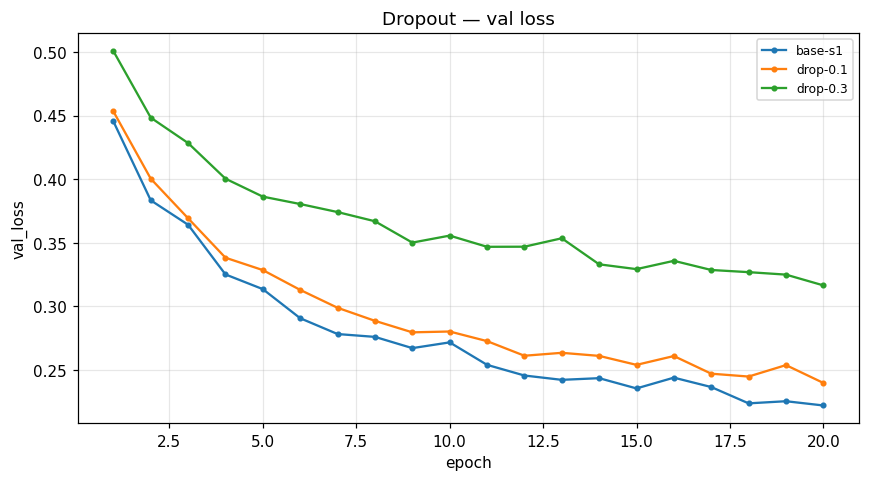

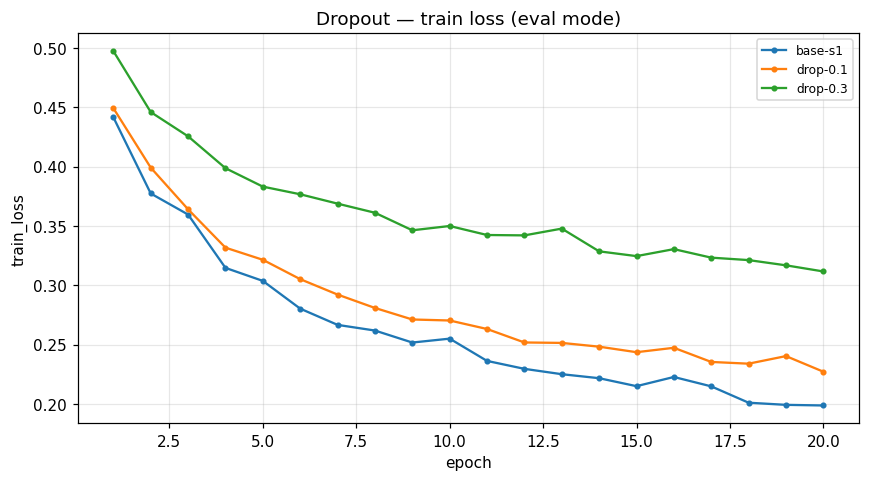

In [8]:
# ===== Chủ đề 4 — dropout =====
DROP_IDS = []
for q in (0.1, 0.3):
    run_exp(f"drop-{q:g}", "dropout", f"dropout q={q:g} sau ReLU của lớp ẩn", dropout=q)
    DROP_IDS.append(f"drop-{q:g}")
show_table(DROP_IDS, "dropout (gap_cuối = final_val_loss - final_train_loss, train đo ở eval mode)")
compare(DROP_IDS, "val_loss", "dropout", "Dropout — val loss")
compare(DROP_IDS, "train_loss", "dropout_train_loss", "Dropout — train loss (eval mode)")

**Đối chiếu (dropout):** Khớp dự đoán. `drop-0.1` (0.8339, ΔF1 = −0.0260) và `drop-0.3` (0.7820, −0.0779) đều kém baseline, đều vượt 2σ, và mức giảm tăng theo q. Khoảng cách val − train (cả hai đo ở `eval()`) co lại: 0.0235 → 0.0128 → 0.0049, và train loss tăng theo q. Baseline **chưa quá khớp** (Part 2), nên dropout không có quá khớp để chữa. Nó chỉ làm giảm năng lực hiệu dụng và thêm nhiễu vào gradient, nên cả train lẫn val đều tệ đi; khoảng cách hẹp lại vì train tệ đi nhanh hơn val. Dropout chỉ đáng thử lại khi mô hình lớn hơn và bắt đầu quá khớp, ví dụ M-wide với gap 0.0317 khi chạy lâu hơn.

### Thí nghiệm `clip-*` — chủ đề `clipping`
**Chọn ngưỡng c từ `grad_norm` baseline:** ở `base-s1`, `grad_norm` trung bình mỗi epoch giảm từ ≈ 0.38 xuống ≈ 0.34 (ô dưới in lại). Chọn **c = 0.35**, nằm giữa khoảng đó, để clipping thực sự kích hoạt ở một phần các bước. Tỉ lệ bước bị cắt được ghi trong `history["clip_frac"]`.

**Thí nghiệm:**
1. `clip-0.35`: lr 0.3, có clip, so với baseline.
2. Phản chứng ở lr cao, ×10 = 3.0: `clip-highlr3-noclip` so với `clip-highlr3-c0.35` (cùng lr, chỉ khác có/không clip).

**Dự đoán trước:**
1. Với c = 0.35 ở lr 0.3, khoảng một nửa số bước bị cắt nhưng chỉ cắt nhẹ (hệ số c/‖g‖ ≈ 0.9), nên kết quả gần baseline, trong nhiễu.
2. Ở lr 3.0 không clip, bước cập nhật quá lớn nên loss sẽ dao động mạnh hoặc thành NaN (`diverged`), và `grad_norm` có gai. Có clip thì độ dài mỗi bước bị chặn ≤ lr·c, nên huấn luyện ổn định hơn, nhưng vẫn kém baseline vì lr quá lớn.

grad_norm TB mỗi epoch của base-s1: [0.379, 0.368, 0.366, 0.368, 0.359, 0.358, 0.356, 0.352, 0.353, 0.35, 0.344, 0.347, 0.344, 0.344, 0.341, 0.341, 0.341, 0.34, 0.336, 0.336]
min = 0.336, max = 0.379  ->  chọn c = 0.35
clip-0.35              tỉ lệ bước bị cắt theo epoch: [0.8, 0.83, 0.8, 0.82, 0.76, 0.73, 0.71, 0.69, 0.65, 0.64, 0.59, 0.63, 0.57, 0.55, 0.53, 0.53, 0.51, 0.5, 0.5, 0.44]
                       grad_norm max theo epoch: [2.84, 0.69, 0.77, 0.64, 0.6, 0.65, 0.72, 0.56, 0.72, 0.58, 0.54, 0.73, 0.67, 0.63, 0.65, 0.61, 1.03, 0.51, 0.62, 0.81]
clip-highlr3-noclip    tỉ lệ bước bị cắt theo epoch: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                       grad_norm max theo epoch: [7813.55, 0.27, 0.25, 0.25, 0.3, 0.28, 0.32, 0.32, 0.25, 0.3, 0.29, 0.26, 0.26, 0.26, 0.28, 0.29, 0.29, 0.28, 0.26, 0.28]
clip-highlr3-c0.35     tỉ lệ bước bị cắt theo epoch: [0.4, 0.07, 0.07, 0.05, 0.02, 0.02, 0.01, 0.02, 0.01, 0.01, 0.02

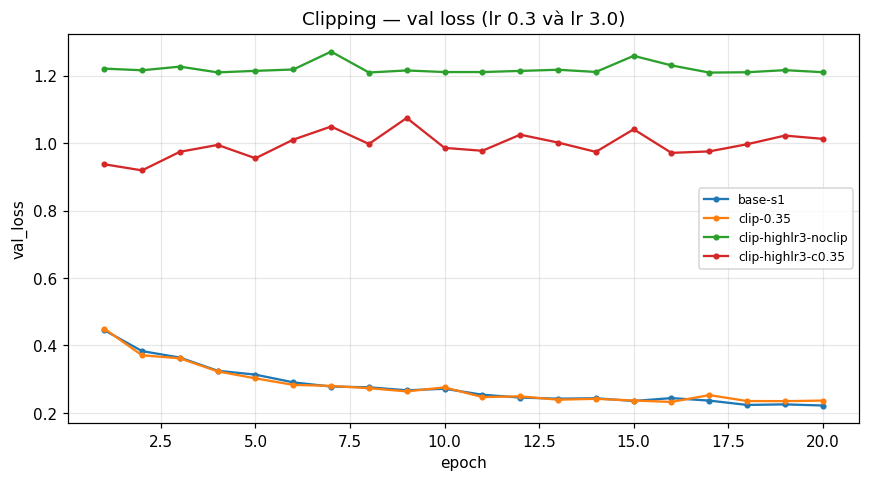

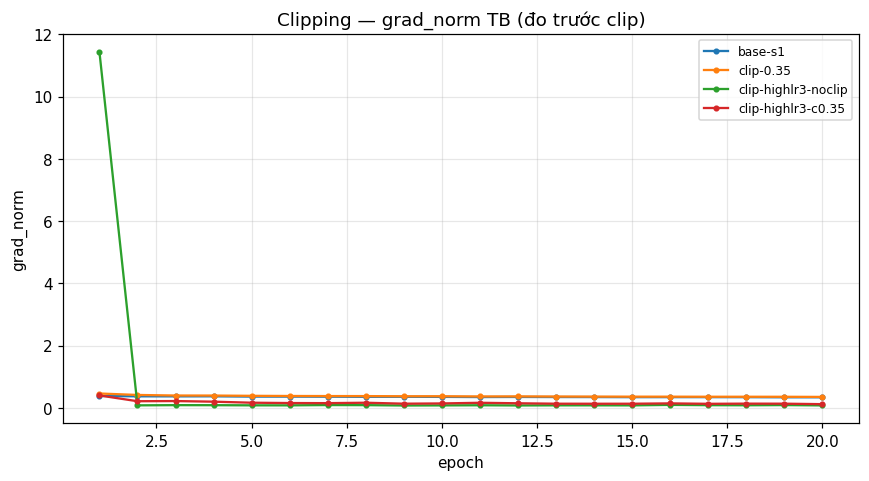

In [9]:
# ===== Chủ đề 5 — gradient clipping =====
gn = BASE["history"]["grad_norm"]
print("grad_norm TB mỗi epoch của base-s1:", [round(v, 3) for v in gn])
print(f"min = {min(gn):.3f}, max = {max(gn):.3f}  ->  chọn c = 0.35")
CLIP_C = 0.35
CLIP_IDS = []
run_exp("clip-0.35", "clipping", f"clip_norm={CLIP_C}, lr 0.3", clip_norm=CLIP_C)
CLIP_IDS.append("clip-0.35")
run_exp("clip-highlr3-noclip", "clipping", "lr 3.0 (x10), KHÔNG clip — phản chứng", lr=3.0)
run_exp("clip-highlr3-c0.35", "clipping", f"lr 3.0 (x10), clip_norm={CLIP_C}", lr=3.0, clip_norm=CLIP_C)
CLIP_IDS += ["clip-highlr3-noclip", "clip-highlr3-c0.35"]
for e in CLIP_IDS:
    if e in ALL_RUNS:
        h = ALL_RUNS[e]["history"]
        print(f"{e:22s} tỉ lệ bước bị cắt theo epoch: {[round(v, 2) for v in h['clip_frac']]}")
        print(f"{'':22s} grad_norm max theo epoch: {[round(v, 2) for v in h['grad_norm_max']]}")
show_table(CLIP_IDS, "clipping")
compare(CLIP_IDS, "val_loss", "clipping", "Clipping — val loss (lr 0.3 và lr 3.0)")
compare(CLIP_IDS, "grad_norm", "clipping_grad_norm", "Clipping — grad_norm TB (đo trước clip)")

**Đối chiếu (clipping):**
- **Phản chứng ở lr 3.0, khớp dự đoán và còn nặng hơn:** không clip, `grad_norm` max của epoch 1 vọt lên **7 813** (các epoch sau ≈ 0.25–0.3), rồi mô hình sụp về đoán lớp đa số (`clip-highlr3-noclip`: val acc 0.4876, macro-F1 0.0936). Một bước với ‖g‖ ≈ 7 813 và lr 3 dịch tham số hàng nghìn đơn vị, làm hỏng mạng ngay từ đầu. Cờ `diverged` không bật vì loss không thành NaN/inf; mạng chỉ "chết" (đầu ra không đổi). Đây là một kiểu thất bại cờ NaN không bắt được. Có clip (`clip-highlr3-c0.35`): mỗi bước bị chặn ở lr·c ≈ 1.05, nên mạng không sụp ngay. Kết quả tốt hơn rõ so với không clip (macro-F1 0.2577 so với 0.0936), nhưng vẫn rất kém baseline vì lr 3 vẫn quá lớn. Clipping chặn gai, không sửa được một lr sai.
- **Khác dự đoán ở lr 0.3:** `clip-0.35` kém baseline ngoài nhiễu (0.8449, ΔF1 = −0.0150), không "gần baseline" như dự đoán. Lý do nằm ở `clip_frac`: 80% số bước bị cắt ở epoch 1 và vẫn 44% ở epoch 20. c = 0.35 nằm **ngay giữa** vùng `grad_norm` bình thường (0.34–0.38), nên clipping can thiệp vào hầu hết các bước bình thường, thực chất là giảm lr hiệu dụng. Nó không chỉ cắt các "gai" thật (trong `clip-0.35`, `grad_norm` max mỗi epoch đo trước khi cắt phần lớn 0.5–0.8, có gai 1.03 và 2.84). Muốn clipping chỉ chặn gai, c nên đặt trên vùng bình thường, ví dụ c ≈ 1. Đề xuất này chưa được chạy kiểm chứng.

### Thí nghiệm `amp-fp16`, `amp-bf16` — chủ đề `amp`
**Thiết kế:** FP16 dùng `torch.autocast(dtype=float16)` + `GradScaler`, `unscale_` trước khi đo và clip gradient. BF16 dùng `autocast(dtype=bfloat16)`, không có GradScaler. Tham số vẫn ở FP32. Đo thời gian mỗi epoch (có `synchronize`), bộ nhớ cực đại và metric.

**Vì sao FP16 cần nhân loss với s còn BF16 thì không:** FP16 có 5 bit mũ, giá trị dương nhỏ nhất ≈ 6e-8 (subnormal). Gradient nhỏ hơn mức này bị làm tròn về 0 (underflow), nên phải nhân loss với s rồi chia lại trước khi cập nhật. BF16 có 8 bit mũ, cùng khoảng giá trị với FP32 (≈ 1e-38), nên gradient nhỏ không bị underflow. Đổi lại, BF16 chỉ có 7 bit phần định trị, kém chính xác hơn.

**Dự đoán trước:** M-base rất nhỏ (48k tham số, lô 512), nên thời gian chủ yếu là chi phí gọi kernel và đồng bộ, không phải phép nhân ma trận. Vì vậy FP16 sẽ **không nhanh hơn**, thậm chí chậm hơn do thêm bước ép kiểu và GradScaler. Bộ nhớ chỉ giảm ít, metric nằm trong nhiễu. T4 không có phần cứng BF16, nên BF16 có thể báo lỗi hoặc chạy chậm (giả lập). Nếu không chạy được, lý do được ghi lại.

GPU: Tesla T4
torch.cuda.is_bf16_supported() = True

=== mixed precision (s/epoch và MB là thời gian/bộ nhớ đo được) ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
amp-fp16                      20   0.2215   0.9132  0.8577  -0.0022     không   0.0266         6    1.70    167  False
amp-bf16                      20   0.2250   0.9102  0.8520  -0.0078        CÓ   0.0233         7    1.51    167  False


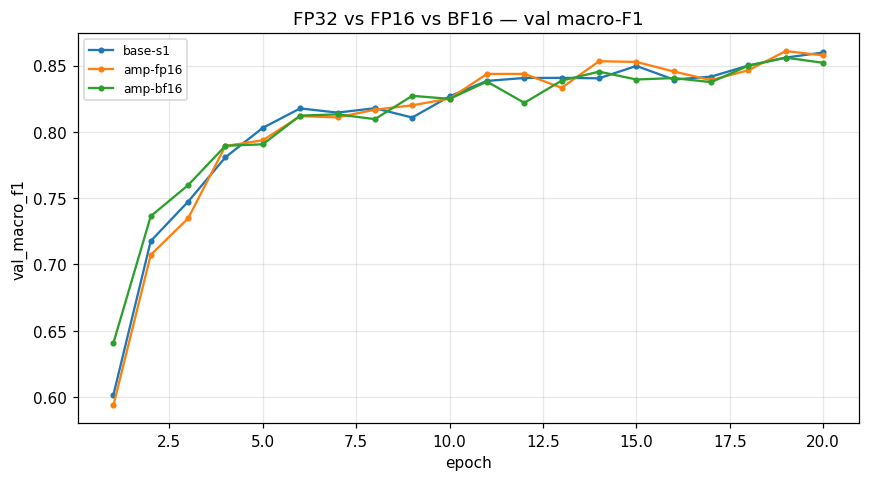

In [10]:
# ===== Chủ đề 6 — mixed precision =====
print("GPU:", torch.cuda.get_device_name(0) if device == "cuda" else device)
print("torch.cuda.is_bf16_supported() =", torch.cuda.is_bf16_supported() if device == "cuda" else None)
AMP_IDS = []
run_exp("amp-fp16", "amp", "FP16 autocast + GradScaler", precision="fp16")
AMP_IDS.append("amp-fp16")
run_exp("amp-bf16", "amp", "BF16 autocast (không GradScaler)", precision="bf16",
        notes="T4 không có phần cứng BF16 (sm_75): nếu chạy được là qua giả lập")
AMP_IDS.append("amp-bf16")
show_table(AMP_IDS, "mixed precision (s/epoch và MB là thời gian/bộ nhớ đo được)")
compare(AMP_IDS, "val_macro_f1", "amp", "FP32 vs FP16 vs BF16 — val macro-F1")

**Đối chiếu (amp):**
- **FP16 khớp dự đoán:** metric trong nhiễu (`amp-fp16`: 0.8577, ΔF1 = −0.0022), và **chậm hơn** FP32: 1.70 s/epoch so với 1.34 s (+27%). Bộ nhớ cực đại không đổi (167 MB), vì tham số và optimizer vẫn ở FP32 và kích hoạt của mạng nhỏ này chỉ chiếm phần nhỏ. Với M-base, chi phí ép kiểu của autocast và các bước của GradScaler (scale, unscale, kiểm tra inf) lớn hơn phần tiết kiệm từ phép nhân ma trận FP16. Kết luận "mixed precision nhanh hơn" **không đúng** với mạng này trên T4.
- **BF16 khác dự đoán:** `torch.cuda.is_bf16_supported()` trả về `True` và lần chạy không báo lỗi, nên dự đoán "BF16 có thể lỗi" sai. Tuy vậy T4 (Turing, sm_75) không có tensor core BF16. PyTorch vẫn chạy được, nhưng nhiều khả năng không qua đường tăng tốc phần cứng; điều này phù hợp với việc BF16 cũng chậm hơn FP32 (1.51 s/epoch). Đây là suy luận, chưa đo trực tiếp. Macro-F1 BF16 = 0.8520 (ΔF1 = −0.0078), **vừa chạm** ngưỡng 2σ = 0.0074. Với 1 seed và σ ước lượng từ 3 seed, đây là "chưa kết luận được" chứ chưa phải bằng chứng BF16 kém hơn. Cơ chế có thể xảy ra là BF16 chỉ có 7 bit phần định trị, nên logits và gradient bị làm tròn thô hơn FP16 (10 bit).

### Thí nghiệm `init-*` — chủ đề `init`
**Thiết kế:** so với He (baseline): `zeros` (W = 0), `normal` (W ~ N(0, 0.01²)), `xavier` (`xavier_normal_`, Var = 2/(n_vào + n_ra), không phải 1/n_vào của slide), `default` (khởi tạo mặc định của `nn.Linear`: kaiming_uniform với a = √5, Var = 1/(3·n_vào)). Mọi bias = 0, trừ `default` (giữ bias mặc định). Ở bước 0, đo độ lệch chuẩn kích hoạt **sau mỗi ReLU và ở logits** trên 4 096 mẫu val cố định, cùng loss bước 0.

**Dự đoán trước:**
- `zeros`: mọi W = 0 nên h₁ = ReLU(0) = 0 và h₂ = 0. Gradient của W₃ = h₂ᵀδ = 0. Gradient lan về W₂ và W₁ đều nhân với W phía sau (= 0), nên cũng bằng 0. Chỉ b₃ nhận gradient (b₁, b₂ cũng không, vì đạo hàm ReLU tại 0 bằng 0 trong PyTorch). Mọi nơ-ron trong một lớp giống hệt nhau (đối xứng) và không bao giờ khác đi. Mạng chỉ học được tần suất lớp qua b₃, nên luôn đoán lớp đa số: val acc ≈ 0.4876, macro-F1 ≈ 0.094.
- `normal(0.01)`: std kích hoạt co lại khoảng một bậc (≈ 6–15 lần) qua mỗi lớp, logits ≈ 0 nên loss bước 0 rất sát ln 7. Gradient của lớp đầu nhỏ nên vài epoch đầu học chậm. Mạng chỉ có 3 lớp nên vẫn học được, kết quả cuối có thể kém hơn baseline một chút.
- `xavier`, `default`: phương sai nhỏ hơn He (khoảng 1.5–6 lần) nên kích hoạt nhỏ dần qua các lớp, nhưng với 3 lớp thì chưa đến mức tắt hẳn như biểu đồ "30 lớp ReLU". Kết quả cuối gần baseline, trong nhiễu.

init      std h1 (sau ReLU)  std h2 (sau ReLU)  std logits  loss bước 0 (val)
he                   0.3901             0.3661      0.5773             2.2691
zeros                0.0000             0.0000      0.0000             1.9459
normal               0.0203             0.0022      0.0003             1.9460
xavier               0.1628             0.1248      0.1916             2.0222
default              0.1603             0.0678      0.0585             1.9830

init=zeros, chuẩn gradient sau một lần backward():
  net.0.weight 0.000000
  net.0.bias   0.000000
  net.2.weight 0.000000
  net.2.bias   0.000000
  net.4.weight 0.000000
  net.4.bias   0.496712

=== khởi tạo ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
init-zeros                    16   1.2053   0.4876  0.0936  -0.7662        CÓ

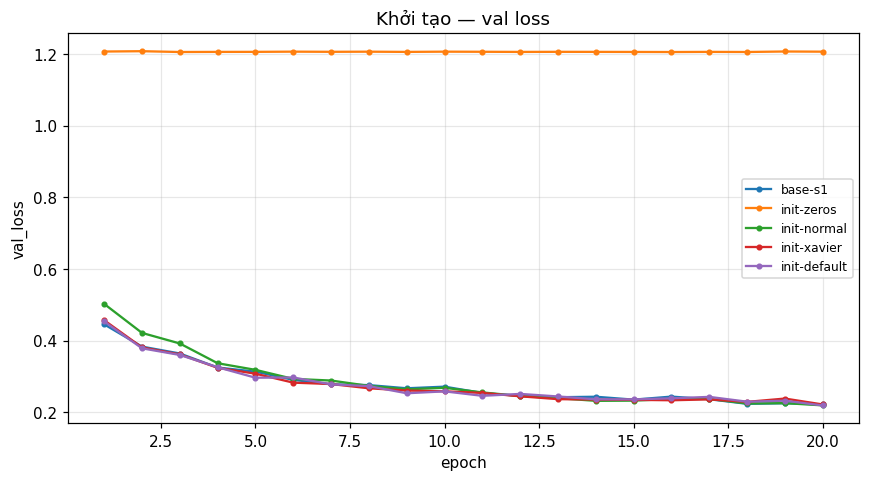

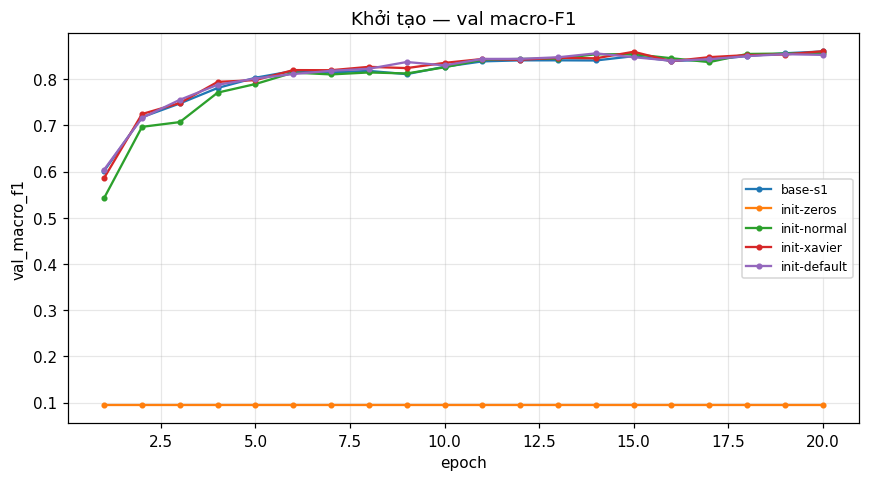

In [11]:
# ===== Chủ đề 7 — khởi tạo =====
X_probe = data["X_val"][:4096]
print(f"{'init':8s} {'std h1 (sau ReLU)':>18s} {'std h2 (sau ReLU)':>18s} {'std logits':>11s} {'loss bước 0 (val)':>18s}")
for init in ("he", "zeros", "normal", "xavier", "default"):
    set_seed(1)
    m = MLP(hidden=(256, 128), init=init).to(device)
    stds = activation_stats(m, X_probe)
    l0 = evaluate(m, data["X_val"], data["y_val"])["loss"]
    print(f"{init:8s} {stds[0]:>18.4f} {stds[1]:>18.4f} {stds[2]:>11.4f} {l0:>18.4f}")

# zeros: gradient từng tham số sau một lần backward (kiểm tra dự đoán về đối xứng)
set_seed(1)
m0 = MLP(hidden=(256, 128), init="zeros").to(device)
m0.train()
F.cross_entropy(m0(data["X_tr"][:512]), data["y_tr"][:512]).backward()
print("\ninit=zeros, chuẩn gradient sau một lần backward():")
for name, p in m0.named_parameters():
    print(f"  {name:12s} {p.grad.norm().item():.6f}")

INIT_IDS = []
for init in ("zeros", "normal", "xavier", "default"):
    run_exp(f"init-{init}", "init", f"khởi tạo {init} (thay He)", init=init)
    INIT_IDS.append(f"init-{init}")
show_table(INIT_IDS, "khởi tạo")
compare(INIT_IDS, "val_loss", "init", "Khởi tạo — val loss")
compare(INIT_IDS, "val_macro_f1", "init_f1", "Khởi tạo — val macro-F1")

**Đối chiếu (init):**
- **`zeros` khớp đúng dự đoán về cơ chế:** std kích hoạt bằng 0 ở mọi lớp, loss bước 0 = 1.9459 = ln 7 chính xác (mọi logit bằng 0 nên softmax đều 1/7). Sau một lần `backward()`, **chỉ `net.4.bias` (b₃) có gradient khác 0 (0.4967)**; mọi `W` và b₁, b₂ đều bằng 0. Mạng chỉ học được tần suất lớp qua b₃, nên `init-zeros` hội tụ về đoán lớp đa số: val acc 0.4876, macro-F1 0.0936, đúng bằng mốc "đoán đa số". Tính đối xứng không bao giờ bị phá vỡ.
- **`normal(0.01)`:** std co rất mạnh qua các lớp (0.0203 → 0.0022 → 0.0003), loss bước 0 = 1.9460 sát ln 7, khớp dự đoán. Mạng chỉ có 3 lớp nên vẫn học được: kết quả 0.8558 (ΔF1 = −0.0041), **trong nhiễu**, chỉ chậm hơn baseline 1 epoch để đạt val acc 0.88.
- **`xavier`** (std 0.163 → 0.125 → 0.192, loss bước 0 = 2.0222) và **`default`** (0.160 → 0.068 → 0.059, loss bước 0 = 1.9830) đều **trong nhiễu** (+0.0006 và −0.0074; `default` nằm đúng ở biên ngưỡng). Với 3 lớp, khác biệt phương sai khởi tạo chưa đủ để kích hoạt tắt dần như biểu đồ "30 lớp ReLU" của slide. Thứ tự std kích hoạt (He > xavier ≈ default > normal ≫ zeros) khớp lý thuyết.
- **Quay lại Part 1:** trong 5 cách khởi tạo, He có loss bước 0 cao nhất (2.2691) vì phương sai lớn nhất làm logits ban đầu phân tán nhất (std 0.577). Điều này xác nhận độ lệch so với ln 7 ở Part 1 là hệ quả của phương sai khởi tạo, không phải lỗi pipeline.

### Tổng hợp Part 3 và chọn cấu hình cuối cùng (chỉ bằng val)
Ô dưới xếp hạng mọi lần chạy theo val macro-F1 tại best epoch, đánh dấu những lần vượt ngưỡng nhiễu 2σ so với `base-s1`. Quyết định cấu hình cuối (giữ baseline, hoặc kết hợp các thay đổi vượt nhiễu rồi chạy lại 2–3 seed trên val) được ghi ở ô kế tiếp, **trước** Part 4.

In [12]:
# ===== Tổng hợp mọi lần chạy Part 3 (xếp theo val macro-F1) =====
ranked = sorted([e for e, r in ALL_RUNS.items() if r["summary"]["best_epoch"] is not None],
                key=lambda e: ALL_RUNS[e]["summary"]["val_macro_f1"], reverse=True)
show_table(ranked, "Xếp hạng theo val macro-F1 (chỉ dùng val)")
if FAILED:
    print("\nKhông chạy được:", FAILED)


=== Xếp hạng theo val macro-F1 (chỉ dùng val) ===
exp_id                   best_ep  best_vl  val_acc  val_F1      ΔF1  vượt 2σ? gap_cuối ep→acc.88 s/epoch     MB  diverged
base-s1                       20   0.2221   0.9109  0.8599  +0.0000         -   0.0235         6    1.34    167  False
hp-wide                       20   0.1993   0.9221  0.8721  +0.0122        CÓ   0.0317         5    1.28    183  False
opt-adam-lr0.003              18   0.2142   0.9138  0.8660  +0.0061     không   0.0284         6    1.40    168  False
opt-adamw-lr0.003             19   0.2231   0.9095  0.8615  +0.0016     không   0.0212         6    1.43    168  False
init-xavier                   20   0.2220   0.9125  0.8605  +0.0006     không   0.0245         6    1.29    168  False
lr-0.3                        20   0.2221   0.9109  0.8599  +0.0000     không   0.0235         6    1.34    167  False
amp-fp16                      20   0.2215   0.9132  0.8577  -0.0022     không   0.0266         6    1.70    167  

**Cấu hình cuối cùng (chọn chỉ bằng val):** **M-wide** (`54 → 512 → 256 → 7`, 161 287 tham số). Mọi yếu tố khác giữ nguyên baseline: SGD + momentum 0.9, lr 0.3, CE, batch 512, 20 epoch, He, dropout 0, không clip, FP32.

**Lý do:**
- Trong toàn bộ Part 3, `hp-wide` là cấu hình **duy nhất** tốt hơn `base-s1` ngoài ngưỡng nhiễu (ΔF1 = +0.0122 > 2σ = 0.0074).
- Các thay đổi khác hoặc nằm trong nhiễu (Adam/AdamW lr 0.003, xavier, normal, FP16), hoặc kém hơn rõ. Vì vậy không kết hợp thêm kỹ thuật nào.

**Kiểm chứng với 3 seed** (`hp-wide` = seed 1, `final-wide-s2`, `final-wide-s3`; so với `base-s1..s3` của Part 2):

| | M-wide (3 seed) | baseline M-base (3 seed) | Δ trung bình |
|---|---|---|---|
| val macro-F1 | **0.8686 ± 0.0031** | 0.8580 ± 0.0037 | **+0.0106** |
| val acc | 0.9193 ± 0.0027 | 0.9120 ± 0.0010 | +0.0073 |
| best val loss | 0.2063 ± 0.0068 | 0.2210 ± 0.0015 | −0.0146 |

- Chênh lệch trung bình macro-F1 (+0.0106) **lớn hơn ngưỡng 2σ = 0.0074**. Hai nhóm không chồng lấn: seed M-wide kém nhất (0.8663) vẫn cao hơn seed baseline tốt nhất (0.8603). Sai số chuẩn của hiệu hai trung bình ≈ √(0.0031²/3 + 0.0037²/3) ≈ 0.0028, nên Δ ≈ 3.8 lần sai số chuẩn → bằng chứng khá chắc, dù 3 seed mỗi bên vẫn là cỡ mẫu nhỏ.
- Lưu ý: xét riêng từng seed, `final-wide-s3` (+0.0064) nằm dưới ngưỡng. Kết luận dựa trên trung bình 3 seed, không dựa trên một lần chạy đơn lẻ.
- **Best epoch** của M-wide = 20 / 20 / 18 (epoch có val loss thấp nhất). Val loss vẫn còn giảm gần cuối, gap val − train = 0.026–0.032, nên chưa quá khớp. Part 4 sẽ dùng `best_state` tại best epoch của lần chạy được chọn để dự đoán eval.
- **Chi phí:** 3.4 lần tham số, thời gian mỗi epoch gần như không đổi (1.28–1.38 s so với 1.34 s), bộ nhớ cực đại 176–183 MB so với 167 MB.

Quyết định này được chốt **trước** Part 4; tập eval chưa được dùng ở bất kỳ bước nào.

=== Cấu hình cuối M-wide — 3 seed ===
exp_id        best_ep best_vl val_acc val_F1   ΔF1    vượt 2σ? gap_cuối ep→acc.88 s/epoch  MB  diverged
base-s1          20   0.2221  0.9109  0.8599 +0.0000     -     0.0235     6      1.34   167  False
hp-wide          20   0.1993  0.9221  0.8721 +0.0122    CÓ     0.0317     5      1.28   183  False
final-wide-s2    20   0.2128  0.9167  0.8674 +0.0075    CÓ     0.0310     5      1.38   176  False
final-wide-s3    18   0.2069  0.9191  0.8663 +0.0064   không   0.0255     6      1.37   176  False
val_macro_f1  : M-wide 0.8686 ± 0.0031 | baseline 0.8580 ± 0.0037 | Δ trung bình = +0.0106
val_acc       : M-wide 0.9193 ± 0.0027 | baseline 0.9120 ± 0.0010 | Δ trung bình = +0.0073
best_val_loss : M-wide 0.2063 ± 0.0068 | baseline 0.2210 ± 0.0015 | Δ trung bình = -0.0146
best epoch của từng seed M-wide: [20, 20, 18]


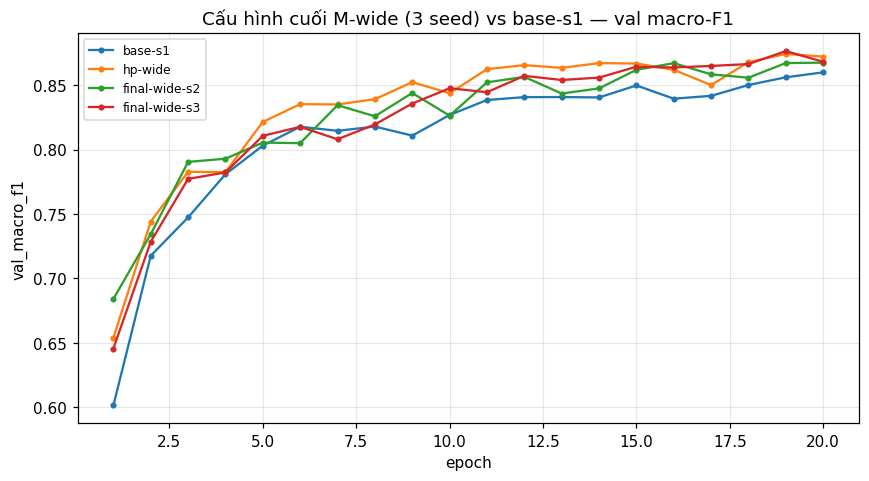

In [13]:
# ===== Cấu hình cuối: M-wide, kiểm chứng với 3 seed (seed 1 = hp-wide) =====
FINAL_CHANGES = {"hidden": (512, 256)}
if "hp-wide" not in ALL_RUNS:          # runtime mới: nạp seed 1 từ JSON của Part 3
    ALL_RUNS["hp-wide"] = load_json("hp-wide")
final_ids = ["hp-wide"]
for s in (2, 3):
    eid = f"final-wide-s{s}"
    exp_cfg_changes = {**FINAL_CHANGES}
    # run_exp luôn đặt seed = 1 -> chạy trực tiếp với seed s
    path = f"{RESULTS_DIR}/{eid}.json"
    if not RERUN and os.path.exists(path):
        r = load_json(eid); print(f"(nạp lại {eid} từ JSON)")
    else:
        r = run_experiment({**cfg, **exp_cfg_changes, "seed": s, "exp_id": eid, "group": "final",
                            "description": f"Cấu hình cuối M-wide, seed {s}", "notes": ""}, data)
        save_result(r, RESULTS_DIR)
    plot_run(r, f"{FIG_DIR}/{eid}.png")
    ALL_RUNS[eid] = r
    final_ids.append(eid)

show_table(final_ids, "Cấu hình cuối M-wide — 3 seed")
for key in ("val_macro_f1", "val_acc", "best_val_loss"):
    fv = np.array([ALL_RUNS[e]["summary"][key] for e in final_ids])
    bv = np.array([r["summary"][key] for r in base_runs])
    print(f"{key:14s}: M-wide {fv.mean():.4f} ± {fv.std(ddof=1):.4f}   |   baseline {bv.mean():.4f} ± {bv.std(ddof=1):.4f}"
          f"   |   Δ trung bình = {fv.mean() - bv.mean():+.4f}")
print("best epoch của từng seed M-wide:", [ALL_RUNS[e]["summary"]["best_epoch"] for e in final_ids])
compare(final_ids, "val_macro_f1", "final", "Cấu hình cuối M-wide (3 seed) vs base-s1 — val macro-F1")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary